# Find nbr electric vehicles + forecast

imports

In [23]:
import polars as pl
import requests
import numpy as np
from pathlib import Path
import zipfile
import matplotlib.pyplot as plt
from datetime import date
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import os
import datetime
from dateutil.relativedelta import relativedelta
from statistics import NormalDist
import warnings



## Configurable Parameters
Edit this cell first when you want to change the forecast window, scenario interval, or key dataset boundaries.

In [24]:
# Geography / project scope
GEOGRAPHY_LABEL = "Spain"

# Data download window
DOWNLOAD_START_YEAR = 2015
DOWNLOAD_END_YEAR = 2026
DOWNLOAD_END_MONTH = 3
TARGET_END_YEAR = 2031

# If needed, you can keep ingestion coverage wider than the forecasting training window
TRAINING_START_YEAR = DOWNLOAD_START_YEAR

# Local folders / portability
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Nbr electric vehicles"
DOWNLOAD_ARCHIVE_FOLDER = DATA_DIR / "mensual_matriculation_202408_202603"
UNZIPPED_FOLDER_NAME = "unzipped"
CACHE_DIR = PROJECT_ROOT / "cache"
PARQUET_CACHE_PATH = CACHE_DIR / "ev_structured_2015_onward.parquet"
USE_PARQUET_CACHE = True
ENABLE_SAFE_CLEANUP = True

# Download source settings
BASE_URL = "https://www.dgt.es/microdatos/salida/{year}/{month}/vehiculos/matriculaciones/export_mensual_mat_{year}{month:02d}.zip"
DOWNLOAD_TIMEOUT_SECONDS = 10

# Forecasting dataset boundaries
TRAINING_START_DATE = datetime.date(TRAINING_START_YEAR, 1, 1)
LAST_COMPLETE_OBSERVED_MONTH = datetime.date(DOWNLOAD_END_YEAR, DOWNLOAD_END_MONTH, 1)
FORECAST_TARGET_END_DATE = datetime.date(TARGET_END_YEAR, 12, 1)

# Scenario settings
SCENARIO_INTERVAL_LEVEL = 0.30  # Change this to change the scenario analysis 
SCENARIO_Z_SCORE = NormalDist().inv_cdf(0.5 + SCENARIO_INTERVAL_LEVEL / 2)
SCENARIO_INTERVAL_LABEL = f"{int(round(SCENARIO_INTERVAL_LEVEL * 100))}%"
REFERENCE_INTERVAL_LEVEL = 0.95
REFERENCE_Z_SCORE = NormalDist().inv_cdf(0.5 + REFERENCE_INTERVAL_LEVEL / 2)

# Forecast targets and reporting
OTHER_RECHARGEABLE_NAME = "OTHER_RECHARGEABLE"
TARGET_SERIES = ["BEV", OTHER_RECHARGEABLE_NAME]
TOTAL_SERIES_NAME = "TOTAL_RECHARGEABLE"
FOCUSED_SUMMARY_YEAR = 2027
PLANNING_TARGET_YEAR = FOCUSED_SUMMARY_YEAR
PLANNING_SCENARIO = "normal"
HYBRID_CHARGING_WEIGHT = 0.35 #= how much a hybrid rechargeable weights in our analysis compared to 1 for full Electric Vehicles
CHARGING_DEMAND_METRIC_NAME = "CHARGING_DEMAND_EQUIVALENT"
SAVE_DIR = "Datathon_Forecasting_Outputs"


## Start by extracting relevant files from 2015 until 2026
### !!!Be Careful!!! Only run this once for the first run! No need to run it each time!

In [25]:
# Where to save files
download_folder = DOWNLOAD_ARCHIVE_FOLDER
download_folder.mkdir(exist_ok=True)

# If a valid Parquet cache already exists, skip the raw download step entirely
cache_required_columns = [
    "source_file", "line_number", "raw_text", "record_date",
    "categoria_vehiculo_electrico", "is_bev", "is_phev",
    "is_reev", "is_rechargeable_ev", "rechargeable_ev_type"
]
cache_is_valid_for_download_skip = False

if USE_PARQUET_CACHE and PARQUET_CACHE_PATH.exists():
    try:
        cache_preview = pl.read_parquet(PARQUET_CACHE_PATH)
        cache_is_valid_for_download_skip = (
            cache_preview.height > 0
            and all(col in cache_preview.columns for col in cache_required_columns)
        )
    except Exception as exc:
        print(f"Parquet cache exists but could not be validated for download skip: {exc}")

if cache_is_valid_for_download_skip:
    print(f"Using validated Parquet cache at {PARQUET_CACHE_PATH}; skipping raw ZIP download.")
    downloaded = 0
    failed = []
else:
    # Define date range
    years = range(DOWNLOAD_START_YEAR, DOWNLOAD_END_YEAR + 1)
    months = range(1, 13)

    base_url = BASE_URL

    downloaded = 0
    failed = []

    for year in years:
        for month in months:
            # Stop at the configured last complete observed month
            if year == DOWNLOAD_END_YEAR and month > DOWNLOAD_END_MONTH:
                break
            
            url = base_url.format(year=year, month=month)
            filename = f"export_mensual_mat_{year}{month:02d}.zip"
            filepath = download_folder / filename

            if filepath.exists():
                print(f"✔ Already exists: {filename}")
                continue

            try:
                response = requests.get(url, timeout=DOWNLOAD_TIMEOUT_SECONDS)
                
                if response.status_code == 200:
                    with open(filepath, "wb") as f:
                        f.write(response.content)
                    print(f"⬇ Downloaded: {filename}")
                    downloaded += 1
                else:
                    failed.append(url)
                    print(f"❌ Failed ({response.status_code}): {filename}")

            except Exception as e:
                failed.append(url)
                print(f"⚠ Error: {filename} -> {e}")

print(f"\n✅ Downloaded {downloaded} files")
print(f"❌ Failed: {len(failed)}")

⬇ Downloaded: export_mensual_mat_201501.zip
⬇ Downloaded: export_mensual_mat_201502.zip
⬇ Downloaded: export_mensual_mat_201503.zip
⬇ Downloaded: export_mensual_mat_201504.zip
⬇ Downloaded: export_mensual_mat_201505.zip
⬇ Downloaded: export_mensual_mat_201506.zip
⬇ Downloaded: export_mensual_mat_201507.zip
⬇ Downloaded: export_mensual_mat_201508.zip
⬇ Downloaded: export_mensual_mat_201509.zip
⬇ Downloaded: export_mensual_mat_201510.zip
⬇ Downloaded: export_mensual_mat_201511.zip
⬇ Downloaded: export_mensual_mat_201512.zip
⬇ Downloaded: export_mensual_mat_201601.zip
⬇ Downloaded: export_mensual_mat_201602.zip
⬇ Downloaded: export_mensual_mat_201603.zip
⬇ Downloaded: export_mensual_mat_201604.zip
⬇ Downloaded: export_mensual_mat_201605.zip
⬇ Downloaded: export_mensual_mat_201606.zip
⬇ Downloaded: export_mensual_mat_201607.zip
⬇ Downloaded: export_mensual_mat_201608.zip
⬇ Downloaded: export_mensual_mat_201609.zip
⬇ Downloaded: export_mensual_mat_201610.zip
⬇ Downloaded: export_mensual_mat

KeyboardInterrupt: 

## Files work

### Cache-aware raw ingestion and reusable Parquet storage

This section keeps the existing raw parsing logic but adds a cached Parquet layer so reruns can skip the heavy text parsing step. The cache is validated before use, and the notebook continues gracefully if some months from 2015 onward are missing.


In [ ]:
# Reusable helpers for cache validation, coverage checks, and disk-usage reporting
def format_bytes(num_bytes):
    num_bytes = float(num_bytes or 0)
    units = ["B", "KB", "MB", "GB", "TB"]
    idx = 0
    while num_bytes >= 1024 and idx < len(units) - 1:
        num_bytes /= 1024
        idx += 1
    return f"{num_bytes:.2f} {units[idx]}"

def get_folder_size_bytes(path):
    path = Path(path)
    if not path.exists():
        return 0
    total = 0
    for item in path.rglob("*"):
        try:
            if item.is_file():
                total += item.stat().st_size
        except OSError:
            continue
    return total

def validate_parquet_cache(parquet_path, required_columns):
    parquet_path = Path(parquet_path)
    result = {
        "is_valid": False,
        "reason": "",
        "data": None,
        "row_count": 0,
        "file_size_bytes": 0,
        "missing_columns": []
    }

    if not parquet_path.exists():
        result["reason"] = "file_missing"
        return result

    try:
        result["file_size_bytes"] = parquet_path.stat().st_size
        cached_df = pl.read_parquet(parquet_path)
    except Exception as exc:
        result["reason"] = f"read_failed: {exc}"
        return result

    missing_columns = [col for col in required_columns if col not in cached_df.columns]
    if missing_columns:
        result["reason"] = "missing_columns"
        result["missing_columns"] = missing_columns
        return result

    if cached_df.height <= 0:
        result["reason"] = "empty_table"
        return result

    result.update({
        "is_valid": True,
        "reason": "ok",
        "data": cached_df,
        "row_count": cached_df.height
    })
    return result

def month_sequence(start_month, end_month):
    months = []
    current = start_month
    while current <= end_month:
        months.append(current)
        current = current + relativedelta(months=1)
    return months

def is_path_within(base_path, candidate_path):
    base_path = Path(base_path).resolve()
    candidate_path = Path(candidate_path).resolve()
    try:
        candidate_path.relative_to(base_path)
        return True
    except ValueError:
        return False


### Build or load the structured EV cache

If the Parquet cache already exists and passes validation, the notebook loads it directly. Otherwise it unzips the available monthly raw files, applies the current parsing logic, writes a compressed Parquet cache, and validates it before proceeding.


In [ ]:
download_folder = DOWNLOAD_ARCHIVE_FOLDER
download_folder.mkdir(parents=True, exist_ok=True)
extract_folder = download_folder / UNZIPPED_FOLDER_NAME
extract_folder.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

project_size_before_cleanup_bytes = get_folder_size_bytes(PROJECT_ROOT)
cache_required_columns = [
    "source_file", "line_number", "raw_text", "record_date",
    "categoria_vehiculo_electrico", "is_bev", "is_phev",
    "is_reev", "is_rechargeable_ev", "rechargeable_ev_type"
]

zip_files = sorted(download_folder.glob("*.zip"))
txt_files = sorted(extract_folder.rglob("*.txt")) if extract_folder.exists() else []
cache_status = validate_parquet_cache(PARQUET_CACHE_PATH, cache_required_columns) if USE_PARQUET_CACHE else {"is_valid": False, "reason": "disabled", "data": None, "row_count": 0, "file_size_bytes": 0}

if USE_PARQUET_CACHE and cache_status["is_valid"]:
    df = cache_status["data"]
    cache_was_rebuilt = False
    print(f"Using validated Parquet cache: {PARQUET_CACHE_PATH}")
else:
    print("Parquet cache not available or invalid. Rebuilding from raw monthly text files...")

    if not txt_files and zip_files:
        for zip_path in zip_files:
            target_dir = extract_folder / zip_path.stem
            target_dir.mkdir(parents=True, exist_ok=True)
            expected_txt = target_dir / f"{zip_path.stem}.txt"
            if expected_txt.exists():
                continue
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(target_dir)

    txt_files = sorted(extract_folder.rglob("*.txt")) if extract_folder.exists() else []
    if not txt_files:
        raise FileNotFoundError(
            f"No extracted .txt files were found in {extract_folder}. "
            f"Run the download step first or keep a valid Parquet cache at {PARQUET_CACHE_PATH}."
        )

    source_files = []
    line_numbers = []
    raw_texts = []

    for txt_file in txt_files:
        with open(txt_file, "r", encoding="latin-1") as f:
            line_number = 0
            for line in f:
                line_number += 1
                raw = line.rstrip("\n")

                if not raw.strip():
                    continue

                if raw.startswith("Veh") and "matriculados" in raw:
                    continue

                if len(raw) >= 8 and raw[:8].isdigit():
                    source_files.append(txt_file.name)
                    line_numbers.append(line_number)
                    raw_texts.append(raw)

    df = pl.DataFrame({
        "source_file": source_files,
        "line_number": line_numbers,
        "raw_text": raw_texts,
    }).with_columns(
        pl.col("raw_text").str.slice(0, 8).alias("record_date")
    )

    df = df.with_columns([
        pl.col("record_date").str.strptime(pl.Date, format="%d%m%Y", strict=False),
        pl.col("raw_text").str.slice(17, 30).str.strip_chars().alias("marca_itv"),
        pl.col("raw_text").str.slice(47, 22).str.strip_chars().alias("modelo_itv"),
        pl.col("raw_text").str.slice(91, 2).str.strip_chars().alias("cod_tipo"),
        pl.col("raw_text").str.slice(93, 1).str.strip_chars().alias("cod_propulsion_itv"),
        pl.col("raw_text").str.slice(453, 4).str.strip_chars().alias("categoria_vehiculo_electrico"),
        pl.col("raw_text").str.slice(457, 6).str.strip_chars().cast(pl.Int64, strict=False).alias("autonomia_vehiculo_electrico"),
    ]).with_columns([
        pl.col("categoria_vehiculo_electrico").replace("", None),
        pl.when(pl.col("categoria_vehiculo_electrico").is_in(["BEV", "HEV", "PHEV", "REEV"]))
          .then(True)
          .otherwise(False)
          .alias("is_electrified"),
        pl.when(pl.col("categoria_vehiculo_electrico") == "BEV")
          .then(True)
          .otherwise(False)
          .alias("is_bev")
    ])

    df = df.with_columns([
        pl.col("categoria_vehiculo_electrico")
          .str.strip_chars()
          .replace("", None),
        (pl.col("categoria_vehiculo_electrico") == "BEV").alias("is_bev"),
        (pl.col("categoria_vehiculo_electrico") == "PHEV").alias("is_phev"),
        (pl.col("categoria_vehiculo_electrico") == "REEV").alias("is_reev"),
        (pl.col("categoria_vehiculo_electrico") == "HEV").alias("is_hev"),
        pl.col("categoria_vehiculo_electrico")
          .is_in(["BEV", "PHEV", "REEV"])
          .alias("is_rechargeable_ev"),
        pl.when(pl.col("categoria_vehiculo_electrico").is_in(["BEV", "PHEV", "REEV"]))
          .then(pl.col("categoria_vehiculo_electrico"))
          .otherwise(None)
          .alias("rechargeable_ev_type")
    ])

    if USE_PARQUET_CACHE:
        df.write_parquet(PARQUET_CACHE_PATH, compression="zstd")
        cache_status = validate_parquet_cache(PARQUET_CACHE_PATH, cache_required_columns)
        if not cache_status["is_valid"]:
            raise ValueError(f"Parquet cache validation failed after writing: {cache_status}")
        df = cache_status["data"]
    cache_was_rebuilt = True

coverage_months_df = (
    df
    .select(pl.col("record_date").dt.truncate("1mo").alias("month"))
    .drop_nulls()
    .unique()
    .sort("month")
)
coverage_start = coverage_months_df["month"].min() if coverage_months_df.height > 0 else None
coverage_end = coverage_months_df["month"].max() if coverage_months_df.height > 0 else None
expected_start = date(DOWNLOAD_START_YEAR, 1, 1)
expected_end = min(LAST_COMPLETE_OBSERVED_MONTH, coverage_end) if coverage_end else LAST_COMPLETE_OBSERVED_MONTH
expected_months = month_sequence(expected_start, expected_end) if expected_end >= expected_start else []
available_months = set(coverage_months_df["month"].to_list())
missing_months = [month for month in expected_months if month not in available_months]

found_2015_onward = coverage_start is not None and coverage_start <= date(2015, 1, 1)
cache_size_bytes = cache_status["file_size_bytes"] if cache_status.get("file_size_bytes") else (PARQUET_CACHE_PATH.stat().st_size if PARQUET_CACHE_PATH.exists() else 0)

print(f"Found {len(zip_files)} zip files and {len(txt_files)} text files available for ingestion.")
print(f"Data from 2015 onward found: {'Yes' if found_2015_onward else 'No'}")
print(f"Coverage start: {coverage_start.strftime('%Y-%m') if coverage_start else 'N/A'}")
print(f"Coverage end: {coverage_end.strftime('%Y-%m') if coverage_end else 'N/A'}")
print(f"Parquet cache saved at: {PARQUET_CACHE_PATH}")
print(f"Parquet cache size: {format_bytes(cache_size_bytes)}")
print(f"Structured dataset shape: {df.shape}")
print(f"Cache rebuilt this run: {'Yes' if cache_was_rebuilt else 'No'}")

if missing_months:
    print("WARNING: Missing months from the expected 2015+ monthly coverage window:")
    print([month.strftime("%Y-%m") for month in missing_months])
else:
    print("No missing months detected within the available 2015+ coverage window.")

df.head()


### Safe cleanup after successful cache validation

Cleanup runs only after the Parquet cache is confirmed to exist, be readable, contain rows, and include the required columns. Only clearly intermediate raw files inside the download archive folder are considered for deletion, and ambiguous project files are kept.


In [ ]:
cleanup_validation = validate_parquet_cache(PARQUET_CACHE_PATH, cache_required_columns)
deleted_records = []
deletion_failures = []
removed_empty_dirs = []

if ENABLE_SAFE_CLEANUP and cleanup_validation["is_valid"]:
    cleanup_candidates = []
    if extract_folder.exists():
        cleanup_candidates.extend(sorted(extract_folder.rglob("*.txt")))
    if download_folder.exists():
        cleanup_candidates.extend(sorted(download_folder.glob("*.zip")))
        cleanup_candidates.extend(sorted(download_folder.rglob("*.csv")))

    allowed_suffixes = {".txt", ".zip", ".csv"}
    for candidate in cleanup_candidates:
        candidate = Path(candidate)
        if not candidate.exists() or not candidate.is_file():
            continue
        if candidate.suffix.lower() not in allowed_suffixes:
            continue
        if not is_path_within(download_folder, candidate):
            continue

        try:
            size_bytes = candidate.stat().st_size
            deleted_records.append({
                "file_type": candidate.suffix.lower(),
                "path": str(candidate.relative_to(PROJECT_ROOT)),
                "size_bytes": size_bytes
            })
            candidate.unlink()
        except Exception as exc:
            deletion_failures.append({"path": str(candidate), "error": str(exc)})

    for folder in sorted([p for p in download_folder.rglob("*") if p.is_dir()], key=lambda x: len(x.parts), reverse=True):
        try:
            if folder == download_folder:
                continue
            if any(folder.iterdir()):
                continue
            folder.rmdir()
            removed_empty_dirs.append(str(folder.relative_to(PROJECT_ROOT)))
        except Exception:
            continue
else:
    print("Cleanup skipped because cache validation failed or cleanup is disabled.")

cleanup_successful = cleanup_validation["is_valid"] and len(deletion_failures) == 0
project_size_after_cleanup_bytes = get_folder_size_bytes(PROJECT_ROOT)
deleted_total_bytes = sum(item["size_bytes"] for item in deleted_records)

if deleted_records:
    cleanup_summary = (
        pl.DataFrame(deleted_records)
        .group_by("file_type")
        .agg([
            pl.len().alias("files_deleted"),
            pl.col("size_bytes").sum().alias("bytes_deleted")
        ])
        .with_columns((pl.col("bytes_deleted") / (1024 ** 3)).round(3).alias("size_deleted_gb"))
        .sort("file_type")
    )
else:
    cleanup_summary = pl.DataFrame({
        "file_type": [],
        "files_deleted": [],
        "bytes_deleted": [],
        "size_deleted_gb": []
    })

print("--- CLEANUP SUMMARY ---")
print(cleanup_summary)
print(f"Deleted files: {len(deleted_records)}")
print(f"Deleted size: {format_bytes(deleted_total_bytes)}")
print(f"Removed empty folders: {len(removed_empty_dirs)}")
if deleted_records:
    print("Deleted file examples:")
    print([item["path"] for item in deleted_records[:10]])
if deletion_failures:
    print("Cleanup failures:")
    print(deletion_failures[:10])

print("\n--- FINAL CACHE / STORAGE STATUS ---")
print(f"Parquet cache ready: {PARQUET_CACHE_PATH}")
print(f"Coverage start: {coverage_start.strftime('%Y-%m') if coverage_start else 'N/A'}")
print(f"Coverage end: {coverage_end.strftime('%Y-%m') if coverage_end else 'N/A'}")
print(f"Project size before cleanup: {project_size_before_cleanup_bytes / (1024 ** 3):.2f} GB")
print(f"Project size after cleanup: {project_size_after_cleanup_bytes / (1024 ** 3):.2f} GB")
print(f"Cleanup successful: {'Yes' if cleanup_successful else 'No'}")


quick check

In [ ]:
df.select([
    pl.col("categoria_vehiculo_electrico"),
    pl.col("is_bev"),
    pl.col("is_phev"),
    pl.col("is_reev"),
    pl.col("is_rechargeable_ev"),
    pl.col("rechargeable_ev_type")
]).head(10)

categoria_vehiculo_electrico,is_bev,is_phev,is_reev,is_rechargeable_ev,rechargeable_ev_type
str,bool,bool,bool,bool,str
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
null,null,null,null,null,null
"""HEV""",false,false,false,false,null


## Do some basic Data Cleaning

### Check Column types

In [ ]:
type_overview = pl.DataFrame({
    "column": list(df.schema.keys()),
    "dtype": [str(dtype) for dtype in df.schema.values()]
})

type_overview

column,dtype
str,str
"""source_file""","""String"""
"""line_number""","""Int64"""
"""raw_text""","""String"""
"""record_date""","""Date"""
"""marca_itv""","""String"""
…,…
"""is_phev""","""Boolean"""
"""is_reev""","""Boolean"""
"""is_hev""","""Boolean"""


Numeric VS non-numeric columns

In [ ]:
numeric_dtypes = {
    pl.Int8, pl.Int16, pl.Int32, pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64
}

numeric_cols = [col for col, dtype in df.schema.items() if dtype in numeric_dtypes]
non_numeric_cols = [col for col in df.columns if col not in numeric_cols]

print("Numeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)

Numeric columns: ['line_number', 'autonomia_vehiculo_electrico']
Non-numeric columns: ['source_file', 'raw_text', 'record_date', 'marca_itv', 'modelo_itv', 'cod_tipo', 'cod_propulsion_itv', 'categoria_vehiculo_electrico', 'is_electrified', 'is_bev', 'is_phev', 'is_reev', 'is_hev', 'is_rechargeable_ev', 'rechargeable_ev_type']


### Rechargeable EV counts

In [ ]:
rechargeable_breakdown = (
    df.filter(pl.col("rechargeable_ev_type").is_not_null())
      .group_by("rechargeable_ev_type")
      .agg(pl.len().alias("n"))
      .sort("n", descending=True)
)

rechargeable_breakdown

rechargeable_ev_type,n
str,u32
"""BEV""",487014
"""PHEV""",442718
"""REEV""",2302


Separate dataframes for the different types of EVs

In [ ]:
df_bev = df.filter(pl.col("is_bev"))
df_phev = df.filter(pl.col("is_phev"))
df_reev = df.filter(pl.col("is_reev"))

### EV Category breakdown

In [ ]:
overall_counts = pl.DataFrame({
    "metric": [
        "total_records",
        "electrified_vehicles",
        "battery_electric_vehicles_bev"
    ],
    "value": [
        df.height,
        df.filter(pl.col("is_electrified")).height,
        df.filter(pl.col("is_bev")).height
    ]
})

overall_counts

metric,value
str,i64
"""total_records""",13781478
"""electrified_vehicles""",3091936
"""battery_electric_vehicles_bev""",487014


### Monthly series for forecasting

In [ ]:
monthly_by_type = (
    df.filter(pl.col("rechargeable_ev_type").is_not_null())
      .with_columns(
          pl.when(pl.col("rechargeable_ev_type") == "BEV")
            .then(pl.lit("BEV"))
            .otherwise(pl.lit(OTHER_RECHARGEABLE_NAME))
            .alias("forecast_ev_bucket")
      )
      .group_by([
          pl.col("record_date").dt.truncate("1mo").alias("month"),
          pl.col("forecast_ev_bucket").alias("rechargeable_ev_type")
      ])
      .agg(pl.len().alias("n_vehicles"))
      .sort(["month", "rechargeable_ev_type"])
)

monthly_by_type

month,rechargeable_ev_type,n_vehicles
date,str,u32
2016-03-01,"""OTHER_RECHARGEABLE""",1
2017-02-01,"""OTHER_RECHARGEABLE""",1
2018-01-01,"""BEV""",1276
2018-01-01,"""OTHER_RECHARGEABLE""",395
2018-02-01,"""BEV""",770
…,…,…
2026-02-01,"""BEV""",11464
2026-02-01,"""OTHER_RECHARGEABLE""",13685
2026-03-01,"""BEV""",14568


Wide format version

In [ ]:
monthly_by_type_wide = (
    monthly_by_type
    .pivot(
        values="n_vehicles",
        index="month",
        on="rechargeable_ev_type"
    )
    .sort("month")
    .fill_null(0)
)

monthly_by_type_wide

month,OTHER_RECHARGEABLE,BEV
date,u32,u32
2016-03-01,1,0
2017-02-01,1,0
2018-01-01,395,1276
2018-02-01,377,770
2018-03-01,343,1562
…,…,…
2025-12-01,14446,13808
2026-01-01,10084,8213
2026-02-01,13685,11464


### Seems good

### Prepare for Forecast
From this point onward, `REEV` is merged into `OTHER_RECHARGEABLE` for forecasting and charging-infrastructure planning. The raw REEV counts are still kept earlier in the notebook for transparency.

In [ ]:
# 1. Audit the raw Polars DataFrame (monthly_by_type_wide)
print("--- RAW POLARS DATA AUDIT ---")
print(f"Shape: {monthly_by_type_wide.shape}")
print(f"Columns: {monthly_by_type_wide.columns}")
print(f"Date Range: {monthly_by_type_wide['month'].min()} to {monthly_by_type_wide['month'].max()}")
print(f"Null Counts:\n{monthly_by_type_wide.null_count()}")
print("\nFirst 10 rows:")
print(monthly_by_type_wide.head(10))
print("\nLast 10 rows:")
print(monthly_by_type_wide.tail(10))
print("-" * 35)

# 2. Define target boundaries (Rule 6)
start_date = TRAINING_START_DATE
end_date = LAST_COMPLETE_OBSERVED_MONTH

# 3. Create cleaned forecasting dataset
# REEV is merged into OTHER_RECHARGEABLE for forecasting and infrastructure planning
forecast_df_clean = (
    monthly_by_type_wide
    .filter((pl.col("month") >= start_date) & (pl.col("month") <= end_date))
    .select(["month", "BEV", OTHER_RECHARGEABLE_NAME])
    .with_columns(pl.all().exclude("month").cast(pl.Int64))
)

# 4. Ensure continuous monthly range with no gaps (Rule 6)
# Create a sequence of all expected months
full_month_seq = pl.date_range(start_date, end_date, interval="1mo", eager=True).alias("month").to_frame()

# Check for gaps by comparing heights or joining
if forecast_df_clean.height != full_month_seq.height:
    missing_dates = full_month_seq.join(forecast_df_clean, on="month", how="anti")
    if missing_dates.height > 0:
        print(f"⚠️ WARNING: Found {missing_dates.height} missing monthly gaps. Reindexing and filling with 0.")
        print(f"Missing dates: {missing_dates['month'].to_list()}")
    
    # Left join ensures all months from full_month_seq are present
    forecast_df_clean = full_month_seq.join(forecast_df_clean, on="month", how="left").fill_null(0)

# 5. Add TOTAL_RECHARGEABLE (Rule 7)
forecast_df_clean = forecast_df_clean.with_columns(
    (pl.col("BEV") + pl.col(OTHER_RECHARGEABLE_NAME)).alias(TOTAL_SERIES_NAME)
)

# 6. Final Audit (Rule 8)
print("\n--- FINAL CLEANED DATASET AUDIT (POLARS) ---")
print(f"Final Shape: {forecast_df_clean.shape}")
print(f"Final Date Range: {forecast_df_clean['month'].min()} to {forecast_df_clean['month'].max()}")

# Gap-free validation check
is_gap_free = forecast_df_clean.height == full_month_seq.height
print(f"Is index monthly and gap-free? {is_gap_free}")

print("\nSummary Statistics:")
print(forecast_df_clean.drop("month").describe())
print("-" * 35)

# 7. Output exactly the last 12 months (Rule 9)
forecast_df_clean.tail(12)

--- RAW POLARS DATA AUDIT ---
Shape: (102, 3)
Columns: ['month', 'OTHER_RECHARGEABLE', 'BEV']
Date Range: 2016-03-01 to 2026-04-01
Null Counts:
shape: (1, 3)
┌───────┬────────────────────┬─────┐
│ month ┆ OTHER_RECHARGEABLE ┆ BEV │
│ ---   ┆ ---                ┆ --- │
│ u32   ┆ u32                ┆ u32 │
╞═══════╪════════════════════╪═════╡
│ 0     ┆ 0                  ┆ 0   │
└───────┴────────────────────┴─────┘

First 10 rows:
shape: (10, 3)
┌────────────┬────────────────────┬──────┐
│ month      ┆ OTHER_RECHARGEABLE ┆ BEV  │
│ ---        ┆ ---                ┆ ---  │
│ date       ┆ u32                ┆ u32  │
╞════════════╪════════════════════╪══════╡
│ 2016-03-01 ┆ 1                  ┆ 0    │
│ 2017-02-01 ┆ 1                  ┆ 0    │
│ 2018-01-01 ┆ 395                ┆ 1276 │
│ 2018-02-01 ┆ 377                ┆ 770  │
│ 2018-03-01 ┆ 343                ┆ 1562 │
│ 2018-04-01 ┆ 300                ┆ 1043 │
│ 2018-05-01 ┆ 500                ┆ 989  │
│ 2018-06-01 ┆ 973                ┆ 

month,BEV,OTHER_RECHARGEABLE,TOTAL_RECHARGEABLE
date,i64,i64,i64
2025-04-01,9390,10509,19899
2025-05-01,11415,14466,25881
2025-06-01,14430,15118,29548
2025-07-01,11721,13752,25473
2025-08-01,8776,9074,17850
…,…,…,…
2025-11-01,12526,13646,26172
2025-12-01,13808,14446,28254
2026-01-01,8213,10084,18297


### Define metrics and backtesting formula, and rund the evaluation

In [ ]:
# 1. Metric definitions (Robust and Reusable)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / (denominator + 1e-10)) * 100

def wape(y_true, y_pred):
    # Weighted Absolute Percentage Error
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10) * 100

def mape_safe(y_true, y_pred):
    # Mean Absolute Percentage Error with protection against zero-division
    mask = y_true != 0
    if not np.any(mask): return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 2. Benchmark Model Logic
def predict_naive(history, h):
    last_val = history[-1]
    return np.full(h, last_val)

def predict_snaive(history, h, sp=12):
    # Seasonal Naive: repeat the last full season
    if len(history) < sp:
        return predict_naive(history, h)
    preds = []
    for i in range(h):
        preds.append(history[-(sp - (i % sp))])
    return np.array(preds)

def predict_drift(history, h):
    # Drift: Last value + h * (average change)
    if len(history) < 2:
        return predict_naive(history, h)
    n = len(history)
    slope = (history[-1] - history[0]) / (n - 1)
    return np.array([history[-1] + (i + 1) * slope for i in range(h)])

# 3. Backtesting Framework
def backtest_benchmark(series_name, series_data, model_func, start_origin, step, horizon, total_len):
    folds = []
    origin = start_origin
    fold_idx = 1
    
    while origin + horizon <= total_len:
        train = series_data[:origin]
        test_actual = series_data[origin:origin + horizon]
        
        preds = model_func(train, horizon)
        
        metrics = {
            "Series": series_name,
            "Fold": fold_idx,
            "RMSE": float(rmse(test_actual, preds)),
            "MAE": float(mae(test_actual, preds)),
            "sMAPE": float(smape(test_actual, preds)),
            "WAPE": float(wape(test_actual, preds)),
            "MAPE": float(mape_safe(test_actual, preds))
        }
        folds.append(metrics)
        
        origin += step
        fold_idx += 1
    
    return folds

# 4. Data Preparation: Final Holdout vs Training Portion
# Reserve the last 12 months as total holdout
df_train_portion = forecast_df_clean.head(-12)
df_holdout = forecast_df_clean.tail(12)

n_train = df_train_portion.height
target_series = TARGET_SERIES
benchmarks = {
    "Naive": predict_naive,
    "Seasonal Naive": predict_snaive,
    "Drift": predict_drift
}

print(f"--- Time Series Evaluation Split Details ---")
print(f"Total points: {forecast_df_clean.height}")
print(f"Training portion: {n_train} months")
print(f"Holdout test set: {df_holdout.height} months")
print(f"CV Settings | Initial Window: 60 | Horizon: 12 | Step: 6")
print("-" * 45)

# 5. Run Evaluation
benchmark_cv_results_list = []

for series in target_series:
    series_vals = df_train_portion[series].to_numpy()
    
    for name, func in benchmarks.items():
        results = backtest_benchmark(series, series_vals, func, 60, 6, 12, n_train)
        for r in results:
            r["Model"] = name
        benchmark_cv_results_list.extend(results)

# 6. Aggregation and Summary
benchmark_cv_results = pl.DataFrame(benchmark_cv_results_list)

benchmark_summary = (
    benchmark_cv_results
    .group_by(["Series", "Model"])
    .agg([
        pl.col("RMSE").mean().alias("RMSE"),
        pl.col("MAE").mean().alias("MAE"),
        pl.col("sMAPE").mean().alias("sMAPE"),
        pl.col("WAPE").mean().alias("WAPE"),
        pl.col("MAPE").mean().alias("MAPE")
    ])
    .sort(["Series", "RMSE", "sMAPE"])
)

# 7. Print Results
print("\n--- BENCHMARK CV RESULTS SUMMARY (Averaged across folds) ---")
print(benchmark_summary)
print("-" * 45)

# Safety check for monthly frequency
# Calculate diffs of the month column to ensure they are consistent (roughly 30 days)
# Note: Polars diffs on dates return durations
is_monthly = df_train_portion["month"].sort().diff().drop_nulls().n_unique() <= 4 
print(f"\nTraining index monthly and gap-free? {is_monthly}")

# Last output line
benchmark_summary.tail(12)

--- Time Series Evaluation Split Details ---
Total points: 99
Training portion: 87 months
Holdout test set: 12 months
CV Settings | Initial Window: 60 | Horizon: 12 | Step: 6
---------------------------------------------

--- BENCHMARK CV RESULTS SUMMARY (Averaged across folds) ---
shape: (6, 7)
┌─────────────────┬────────────────┬─────────────┬─────────────┬───────────┬───────────┬───────────┐
│ Series          ┆ Model          ┆ RMSE        ┆ MAE         ┆ sMAPE     ┆ WAPE      ┆ MAPE      │
│ ---             ┆ ---            ┆ ---         ┆ ---         ┆ ---       ┆ ---       ┆ ---       │
│ str             ┆ str            ┆ f64         ┆ f64         ┆ f64       ┆ f64       ┆ f64       │
╞═════════════════╪════════════════╪═════════════╪═════════════╪═══════════╪═══════════╪═══════════╡
│ BEV             ┆ Seasonal Naive ┆ 1896.257066 ┆ 1551.277778 ┆ 26.517683 ┆ 23.957895 ┆ 22.641912 │
│ BEV             ┆ Naive          ┆ 1902.564459 ┆ 1561.805556 ┆ 23.183045 ┆ 24.11734  ┆ 25.76108

Series,Model,RMSE,MAE,sMAPE,WAPE,MAPE
str,str,f64,f64,f64,f64,f64
"""BEV""","""Seasonal Naive""",1896.257066,1551.277778,26.517683,23.957895,22.641912
"""BEV""","""Naive""",1902.564459,1561.805556,23.183045,24.11734,25.761087
"""BEV""","""Drift""",2044.589966,1812.368721,25.860232,28.020444,30.612696
"""OTHER_RECHARGEABLE""","""Seasonal Naive""",1120.287356,973.138889,19.318002,17.69617,17.22136
"""OTHER_RECHARGEABLE""","""Naive""",1439.284395,1237.944444,21.53952,22.4786,24.269449
"""OTHER_RECHARGEABLE""","""Drift""",1714.20862,1552.892106,25.365044,28.157031,30.542239


### Do some more advanced forecasting

In [ ]:
warnings.filterwarnings("ignore")

# Safe imports for advanced models
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
except ImportError:
    ExponentialSmoothing = None

try:
    import pmdarima as pm
except ImportError:
    pm = None

try:
    from prophet import Prophet
except ImportError:
    Prophet = None

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd # Prophet needs pandas internally, sklearn uses numpy

# 1. Candidate Model Wrappers (Signature: func(history, h))

def predict_hw(history, h):
    if ExponentialSmoothing is None:
        raise ImportError("statsmodels not installed")
    # Add a small epsilon if there's any 0 to prevent multiplicative model errors, 
    # but the user requested "trend + seasonality" which can be additive.
    model = ExponentialSmoothing(
        history, 
        trend='add', 
        seasonal='add', 
        seasonal_periods=12, 
        initialization_method='estimated'
    )
    fit_model = model.fit(optimized=True)
    preds = fit_model.forecast(h)
    return np.clip(preds, 0, None)

def predict_hw_damped(history, h):
    if ExponentialSmoothing is None:
        raise ImportError("statsmodels not installed")
    model = ExponentialSmoothing(
        history, 
        trend='add', 
        damped_trend=True, 
        seasonal='add', 
        seasonal_periods=12, 
        initialization_method='estimated'
    )
    fit_model = model.fit(optimized=True)
    preds = fit_model.forecast(h)
    return np.clip(preds, 0, None)

def predict_auto_arima(history, h):
    if pm is None:
        raise ImportError("pmdarima not installed")
    
    # Transform: log1p(y)
    log_y = np.log1p(history)
    
    model = pm.auto_arima(
        log_y, 
        seasonal=True, m=12, stepwise=True,
        information_criterion='aicc',
        start_p=0, max_p=3, start_q=0, max_q=3,
        start_P=0, max_P=2, start_Q=0, max_Q=2,
        out_of_sample_size=h,
        suppress_warnings=True, error_action='ignore'
    )
    log_preds = model.predict(n_periods=h)
    preds = np.expm1(log_preds)
    return np.clip(preds, 0, None)

def predict_ridge(history, h):
    # Regression on log1p(y) with linear/quad trend and month dummies
    n = len(history)
    
    # Fit features
    t_train = np.arange(n).reshape(-1, 1)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    trend_train = poly.fit_transform(t_train)
    
    months_train = np.arange(n) % 12
    X_months_train = np.zeros((n, 12))
    X_months_train[np.arange(n), months_train] = 1
    
    X_train = np.hstack((trend_train, X_months_train))
    y_train = np.log1p(history)
    
    model = RidgeCV(alphas=[0.1, 1.0, 10.0])
    model.fit(X_train, y_train)
    
    # Predict features
    t_test = np.arange(n, n+h).reshape(-1, 1)
    trend_test = poly.transform(t_test)
    
    months_test = np.arange(n, n+h) % 12
    X_months_test = np.zeros((h, 12))
    X_months_test[np.arange(h), months_test] = 1
    
    X_test = np.hstack((trend_test, X_months_test))
    
    log_preds = model.predict(X_test)
    preds = np.expm1(log_preds)
    return np.clip(preds, 0, None)

def predict_prophet(history, h):
    if Prophet is None:
        raise ImportError("prophet not installed")
    
    dates = pd.date_range(start='2018-01-01', periods=len(history), freq='MS')
    df = pd.DataFrame({'ds': dates, 'y': history})
    
    m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=True)
    m.fit(df)
    
    future_dates = pd.date_range(start=dates[-1] + pd.DateOffset(months=1), periods=h, freq='MS')
    future = pd.DataFrame({'ds': future_dates})
    
    fcast = m.predict(future)
    preds = fcast['yhat'].values
    return np.clip(preds, 0, None)

# 2. Setup candidates and evaluate
candidates = {
    "Seasonal Naive": predict_snaive, # Function defined in previous cell
    "Holt-Winters": predict_hw,
    "HW Damped": predict_hw_damped,
    "Auto-ARIMA": predict_auto_arima,
    "Ridge TS": predict_ridge,
    "Prophet": predict_prophet
}

candidate_cv_results_list = []
candidate_failures_list = []

print("Running advanced CV evaluation. This may take a moment if auto-arima runs...")

for series in target_series: # Defined in previous cell
    series_vals = df_train_portion[series].to_numpy()
    
    for name, func in candidates.items():
        try:
            results = backtest_benchmark(series, series_vals, func, 60, 6, 12, n_train)
            for r in results:
                r["Model"] = name
            candidate_cv_results_list.extend(results)
        except Exception as e:
            candidate_failures_list.append({"Series": series, "Model": name, "Error": str(e)})

# 3. Create DataFrames
candidate_cv_summary = pl.DataFrame()
if candidate_cv_results_list:
    candidate_cv_results = pl.DataFrame(candidate_cv_results_list)
    candidate_cv_summary = (
        candidate_cv_results
        .group_by(["Series", "Model"])
        .agg([
            pl.col("RMSE").mean().alias("RMSE"),
            pl.col("MAE").mean().alias("MAE"),
            pl.col("sMAPE").mean().alias("sMAPE")
        ])
        .sort(["Series", "RMSE", "sMAPE", "MAE"])
    )

if candidate_failures_list:
    candidate_failures = pl.DataFrame(candidate_failures_list)
else:
    candidate_failures = pl.DataFrame({"Series": [], "Model": [], "Error": []})

# 4. Apply Selection Rules
selected_model_plan = {}

if not candidate_cv_summary.is_empty():
    summary_dicts = candidate_cv_summary.to_dicts()
    
    for series in target_series:
        series_res = [row for row in summary_dicts if row["Series"] == series]
        if not series_res: continue
        
        best = series_res[0]
        
        # Check rule for ensemble (top 2 within 5% RMSE difference)
        if len(series_res) > 1:
            runner_up = series_res[1]
            rmse1, rmse2 = best["RMSE"], runner_up["RMSE"]
            
            if rmse1 > 0 and rmse2 <= rmse1 * 1.05:
                # Inverse-RMSE weights
                w1 = 1.0 / rmse1
                w2 = 1.0 / rmse2
                total_w = w1 + w2
                selected_model_plan[series] = {
                    "type": "ensemble",
                    "models": [best["Model"], runner_up["Model"]],
                    "weights": [w1/total_w, w2/total_w]
                }
            else:
                selected_model_plan[series] = {
                    "type": "single",
                    "model": best["Model"]
                }
        else:
            selected_model_plan[series] = {
                "type": "single",
                "model": best["Model"]
            }

# 5. Output
print("\n--- CANDIDATE MODEL CV SUMMARY (Sorted by RMSE) ---")
print(candidate_cv_summary)

if not candidate_failures.is_empty():
    print("\n--- CANDIDATE FAILURES (Gracefully skipped) ---")
    print(candidate_failures)

print("\n--- SELECTED MODEL PLAN PER SERIES ---")
for series in target_series:
    if series in selected_model_plan:
        plan = selected_model_plan[series]
        if plan["type"] == "ensemble":
            m1, m2 = plan["models"]
            w1, w2 = plan["weights"]
            print(f"{series}: ENSEMBLE ({m1}: {w1:.2f}, {m2}: {w2:.2f})")
        else:
            print(f"{series}: SINGLE ({plan['model']})")
    else:
        print(f"{series}: NO VALID MODELS FOUND")


Importing plotly failed. Interactive plots will not work.


Running advanced CV evaluation. This may take a moment if auto-arima runs...


19:03:35 - cmdstanpy - INFO - Chain [1] start processing
19:03:36 - cmdstanpy - INFO - Chain [1] done processing
19:03:36 - cmdstanpy - INFO - Chain [1] start processing
19:03:37 - cmdstanpy - INFO - Chain [1] done processing
19:03:37 - cmdstanpy - INFO - Chain [1] start processing
19:03:37 - cmdstanpy - INFO - Chain [1] done processing
19:03:44 - cmdstanpy - INFO - Chain [1] start processing
19:03:44 - cmdstanpy - INFO - Chain [1] done processing
19:03:44 - cmdstanpy - INFO - Chain [1] start processing
19:03:44 - cmdstanpy - INFO - Chain [1] done processing
19:03:45 - cmdstanpy - INFO - Chain [1] start processing
19:03:45 - cmdstanpy - INFO - Chain [1] done processing



--- CANDIDATE MODEL CV SUMMARY (Sorted by RMSE) ---
shape: (12, 5)
┌────────────────────┬────────────────┬─────────────┬─────────────┬───────────┐
│ Series             ┆ Model          ┆ RMSE        ┆ MAE         ┆ sMAPE     │
│ ---                ┆ ---            ┆ ---         ┆ ---         ┆ ---       │
│ str                ┆ str            ┆ f64         ┆ f64         ┆ f64       │
╞════════════════════╪════════════════╪═════════════╪═════════════╪═══════════╡
│ BEV                ┆ Prophet        ┆ 1554.618979 ┆ 1352.903053 ┆ 21.687661 │
│ BEV                ┆ Auto-ARIMA     ┆ 1674.475186 ┆ 1486.4408   ┆ 23.869434 │
│ BEV                ┆ Holt-Winters   ┆ 1760.752235 ┆ 1616.72838  ┆ 24.775847 │
│ BEV                ┆ HW Damped      ┆ 1856.472144 ┆ 1692.363986 ┆ 25.439334 │
│ BEV                ┆ Seasonal Naive ┆ 1896.257066 ┆ 1551.277778 ┆ 26.517683 │
│ …                  ┆ …              ┆ …           ┆ …           ┆ …         │
│ OTHER_RECHARGEABLE ┆ Seasonal Naive ┆ 1120.287356 

### Generate the normal / optimistic / pessimistic forecasts through 2031-12

In [ ]:
warnings.filterwarnings("ignore")

# 1. Determine forecast horizon
forecast_df_clean = forecast_df_clean.filter(pl.col("month") >= TRAINING_START_DATE)
last_date = forecast_df_clean['month'].max()
target_end_date = FORECAST_TARGET_END_DATE

# Calculate months to forecast (h)
h_horizon = (target_end_date.year - last_date.year) * 12 + target_end_date.month - last_date.month

print(f"--- FORECAST CONFIGURATION ---")
print(f"Last observed date: {last_date}")
print(f"Target end date: {target_end_date}")
print(f"Forecast Horizon (h): {h_horizon} months")
print(f"Scenario Interval Level: {SCENARIO_INTERVAL_LABEL}\n")

# 2. Helper to fetch CV RMSE for residual bounds
def get_cv_rmse(series_name, model_name):
    # Try advanced summary first, fallback to benchmark
    try:
        row = candidate_cv_summary.filter((pl.col("Series") == series_name) & (pl.col("Model") == model_name))
        if row.height > 0: return row["RMSE"][0]
    except NameError:
        pass
    
    try:
        row = benchmark_summary.filter((pl.col("Series") == series_name) & (pl.col("Model") == model_name))
        if row.height > 0: return row["RMSE"][0]
    except NameError:
        pass
        
    return 0.0 # fallback

# 3. Model dispatcher (re-uses functions from previous cells)
def generate_point_forecast(series_data, model_name, h):
    # Safely route to the right model function
    if model_name == "Seasonal Naive": return predict_snaive(series_data, h)
    elif model_name == "Holt-Winters": return predict_hw(series_data, h)
    elif model_name == "HW Damped": return predict_hw_damped(series_data, h)
    elif model_name == "Auto-ARIMA": return predict_auto_arima(series_data, h)
    elif model_name == "Ridge TS": return predict_ridge(series_data, h)
    elif model_name == "Prophet": return predict_prophet(series_data, h)
    elif model_name == "Naive": return predict_naive(series_data, h)
    elif model_name == "Drift": return predict_drift(series_data, h)
    else: return predict_snaive(series_data, h) # fallback

# 4. Generate forecasts per series
# We use date objects for months since forecast_df_clean['month'] is a Date column
future_dates = [(last_date + relativedelta(months=i)) for i in range(1, h_horizon + 1)]
forecast_details_list = []

for series in TARGET_SERIES:
    history = forecast_df_clean[series].to_numpy()
    
    plan = selected_model_plan.get(series, {"type": "single", "model": "Seasonal Naive"})
    
    if plan["type"] == "ensemble":
        m1, m2 = plan["models"]
        w1, w2 = plan["weights"]
        
        preds1 = generate_point_forecast(history, m1, h_horizon)
        preds2 = generate_point_forecast(history, m2, h_horizon)
        
        point_preds = (preds1 * w1) + (preds2 * w2)
        
        # Uncertainty approximation: weighted CV RMSE
        rmse1 = get_cv_rmse(series, m1)
        rmse2 = get_cv_rmse(series, m2)
        base_sigma = (rmse1 * w1) + (rmse2 * w2)
        selected_model_name = f"Ensemble ({m1}, {m2})"
        
    else:
        m1 = plan["model"]
        point_preds = generate_point_forecast(history, m1, h_horizon)
        base_sigma = get_cv_rmse(series, m1)
        selected_model_name = m1

    # Ensure no negative point predictions
    point_preds = np.clip(point_preds, 0, None)
    
    # Calculate intervals using sqrt(h) scaling for expanding uncertainty
    h_steps = np.arange(1, h_horizon + 1)
    sigma_h = base_sigma * np.sqrt(h_steps)
    
    lower_scenario = np.clip(point_preds - SCENARIO_Z_SCORE * sigma_h, 0, None)
    upper_scenario = point_preds + SCENARIO_Z_SCORE * sigma_h
    lower95 = np.clip(point_preds - REFERENCE_Z_SCORE * sigma_h, 0, None)
    upper95 = point_preds + REFERENCE_Z_SCORE * sigma_h
    
    # Round to integers
    point_preds = np.round(point_preds).astype(int)
    lower_scenario = np.round(lower_scenario).astype(int)
    upper_scenario = np.round(upper_scenario).astype(int)
    lower95 = np.round(lower95).astype(int)
    upper95 = np.round(upper95).astype(int)
    
    for i in range(h_horizon):
        forecast_details_list.append({
            "month": future_dates[i],
            "vehicle_type": series,
            "point_forecast": point_preds[i],
            "lower_scenario": lower_scenario[i],
            "upper_scenario": upper_scenario[i],
            "lower95": lower95[i],
            "upper95": upper95[i],
            "selected_model": selected_model_name
        })

# 5. Build Final Datasets
forecast_monthly_detail = pl.DataFrame(forecast_details_list)

# 6. Aggregate Totals (TOTAL_RECHARGEABLE)
totals_detail = (
    forecast_monthly_detail
    .group_by("month")
    .agg([
        pl.col("point_forecast").sum().alias("point_forecast"),
        pl.col("lower_scenario").sum().alias("lower_scenario"),
        pl.col("upper_scenario").sum().alias("upper_scenario"),
        pl.col("lower95").sum().alias("lower95"),
        pl.col("upper95").sum().alias("upper95")
    ])
    .with_columns([
        pl.lit(TOTAL_SERIES_NAME).alias("vehicle_type"),
        pl.lit("Aggregated").alias("selected_model")
    ])
)

# Reorder columns to match exactly
totals_detail = totals_detail.select(forecast_monthly_detail.columns)

# Combine series + total
forecast_monthly_detail = pl.concat([forecast_monthly_detail, totals_detail]).sort(["month", "vehicle_type"])

# 7. Create Long format (Scenario mapping)
mapping = {
    "point_forecast": "normal",
    "lower_scenario": "pessimistic",
    "upper_scenario": "optimistic"
}

forecast_monthly_long = (
    forecast_monthly_detail
    .select(["month", "vehicle_type", "point_forecast", "lower_scenario", "upper_scenario"])
    .unpivot( # Polars unpivot (replaces melt)
        index=["month", "vehicle_type"],
        on=["point_forecast", "lower_scenario", "upper_scenario"],
        variable_name="scenario",
        value_name="forecast"
    )
    .with_columns(
        pl.col("scenario").replace(mapping)
    )
    .sort(["month", "vehicle_type", "scenario"])
)

# 8. Create Wide format
forecast_monthly_wide = (
    forecast_monthly_long
    .filter(pl.col("scenario") == "normal") 
    .pivot(
        index="month",
        on="vehicle_type",
        values="forecast"
    )
    .sort("month")
)

# 9. Final Outputs
print("--- FORECAST RESULTS ---")
print(f"Final Long shape: {forecast_monthly_long.shape}")
print(f"Final Detail shape: {forecast_monthly_detail.shape}")
print(f"Final Wide shape: {forecast_monthly_wide.shape}\n")

print("First 12 Detailed Rows:")
print(forecast_monthly_detail.head(12))
print("\nLast 12 Detailed Rows:")
print(forecast_monthly_detail.tail(12))

print("\n--- Totals Preview (Normal Scenario - First 12 months) ---")
print(forecast_monthly_wide.head(12))


19:03:45 - cmdstanpy - INFO - Chain [1] start processing


--- FORECAST CONFIGURATION ---
Last observed date: 2026-03-01
Target end date: 2031-12-01
Forecast Horizon (h): 69 months
Scenario Interval Level: 30%



19:03:45 - cmdstanpy - INFO - Chain [1] done processing
19:03:46 - cmdstanpy - INFO - Chain [1] start processing
19:03:46 - cmdstanpy - INFO - Chain [1] done processing


--- FORECAST RESULTS ---
Final Long shape: (621, 4)
Final Detail shape: (207, 8)
Final Wide shape: (69, 4)

First 12 Detailed Rows:
shape: (12, 8)
┌────────────┬─────────────┬────────────┬────────────┬────────────┬─────────┬─────────┬────────────┐
│ month      ┆ vehicle_typ ┆ point_fore ┆ lower_scen ┆ upper_scen ┆ lower95 ┆ upper95 ┆ selected_m │
│ ---        ┆ e           ┆ cast       ┆ ario       ┆ ario       ┆ ---     ┆ ---     ┆ odel       │
│ date       ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ i64     ┆ i64     ┆ ---        │
│            ┆ str         ┆ i64        ┆ i64        ┆ i64        ┆         ┆         ┆ str        │
╞════════════╪═════════════╪════════════╪════════════╪════════════╪═════════╪═════════╪════════════╡
│ 2026-04-01 ┆ BEV         ┆ 11685      ┆ 11086      ┆ 12284      ┆ 8638    ┆ 14732   ┆ Prophet    │
│ 2026-04-01 ┆ OTHER_RECHA ┆ 12016      ┆ 11593      ┆ 12438      ┆ 9866    ┆ 14165   ┆ Ensemble   │
│            ┆ RGEABLE     ┆            ┆    

### Create evaluation tables, plots, and the 2027 summary

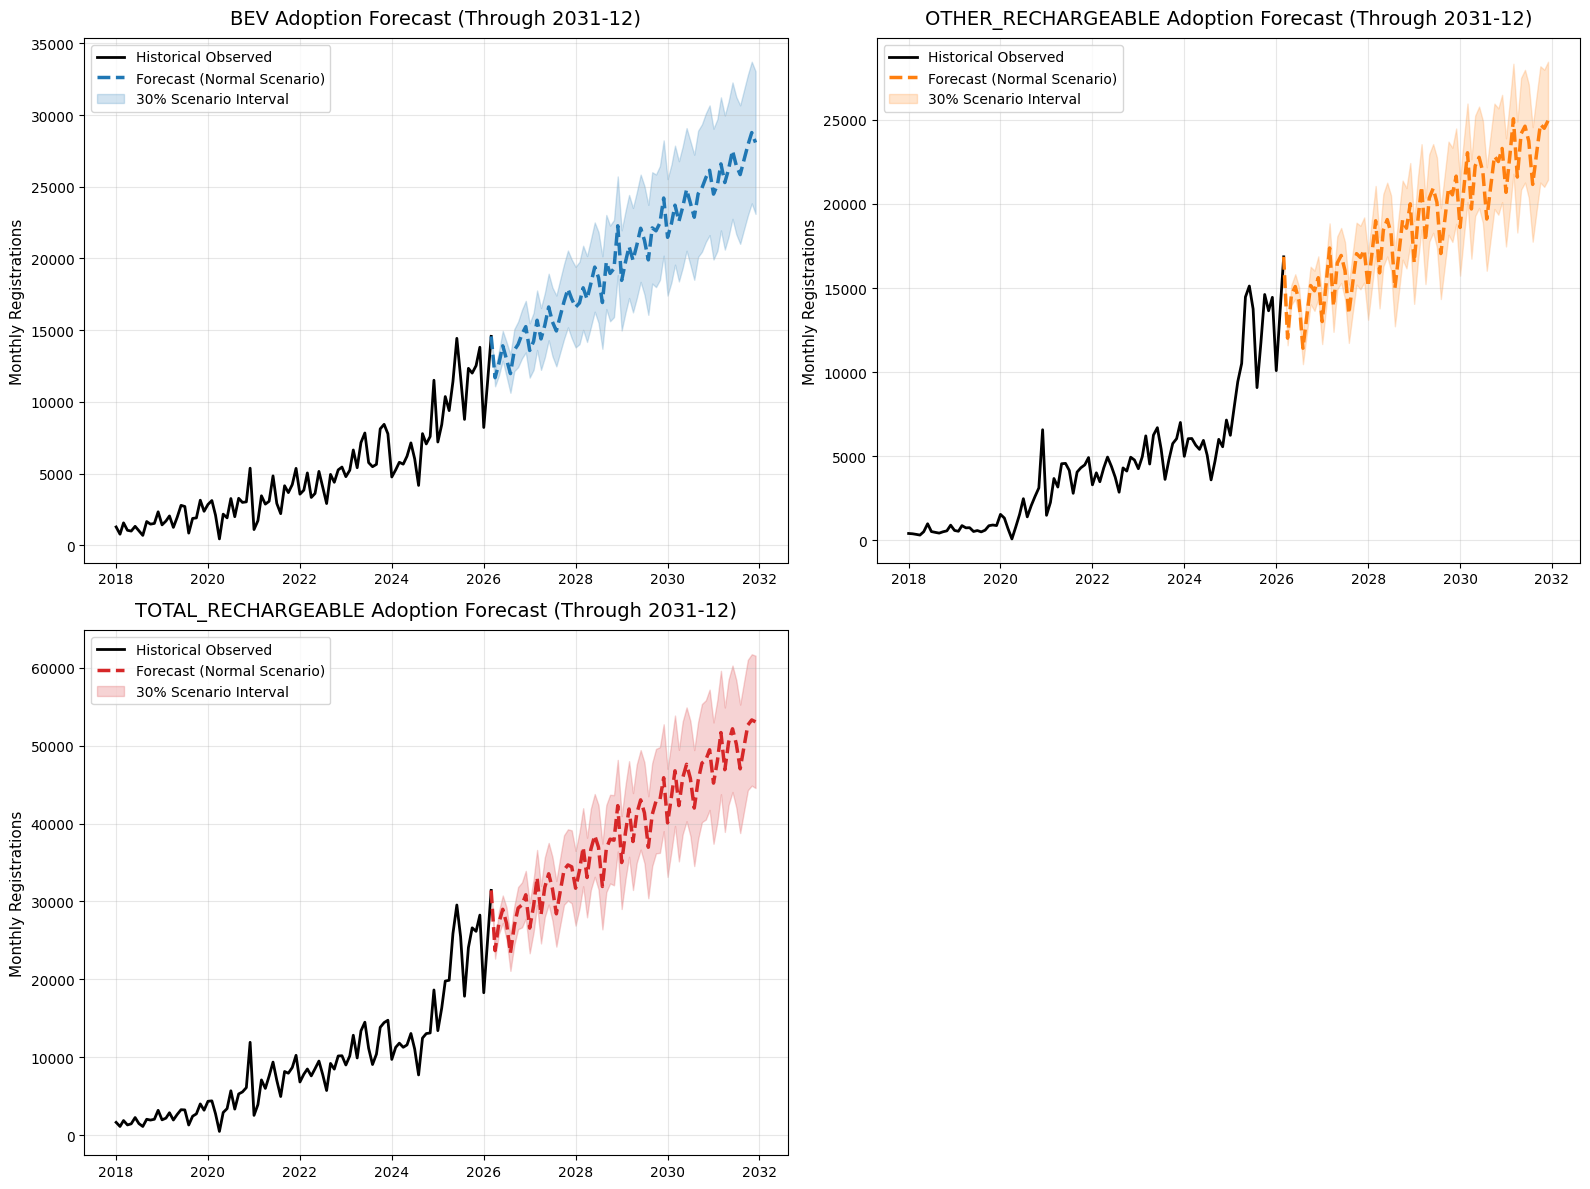

--- FORECAST INTERPRETATION ---
>> BEV Selection: Prophet
>> OTHER_RECHARGEABLE Selection: Ensemble: ['Prophet', 'Seasonal Naive']

Insights & Caveats:
- Trend vs Seasonal: Trend elements are heavily dictating long-term scale growth, though year-end and summer registration spikes remain structurally persistent in the baseline.
- REEV Sparsity: Given the extreme sparsity of REEV records, robust bounded drift or seasonal naive often outperform complex parametric ARIMA constraints which tend to overfit zero-heavy data.
- Pipeline Integrity: The raw dataset was truncated at Mar 2026 (rejecting partial Apr 2026 data) and structurally bounded to start Jan 2018 to bypass historically noisy and low-volume initial years.
---------------------------------------------

FINAL 2027 PLANNING NUMBER (NORMAL SCENARIO)
CHARGING_DEMAND_EQUIVALENT: 254502
Formula: BEV + 0.35 x OTHER_RECHARGEABLE
Assumption: OTHER_RECHARGEABLE counted with weight 0.35 versus BEV = 1.0

--- SAVED ARTIFACTS ---
✔ Datathon_F

scenario,BEV,OTHER_RECHARGEABLE,TOTAL_RECHARGEABLE
str,i64,i64,i64
"""normal""",188388,188896,377284
"""optimistic""",216508,208731,425239
"""pessimistic""",160269,169059,329328


In [ ]:
# 1. Build Annual Summary Table
forecast_annual_summary = (
    forecast_monthly_long
    .with_columns(pl.col("month").dt.year().alias("year"))
    .group_by(["year", "vehicle_type", "scenario"])
    .agg(pl.col("forecast").sum().alias("forecast_total"))
    .sort(["year", "vehicle_type", "scenario"])
)

# Add already-observed months so the current forecast year is annualized properly
observed_current_year = (
    forecast_df_clean
    .filter(pl.col("month").dt.year() == last_date.year)
    .select(["month"] + TARGET_SERIES)
    .with_columns(pl.sum_horizontal([pl.col(series) for series in TARGET_SERIES]).alias(TOTAL_SERIES_NAME))
)

observed_current_year_long = (
    observed_current_year
    .select(["month"] + TARGET_SERIES + [TOTAL_SERIES_NAME])
    .unpivot(index=["month"], variable_name="vehicle_type", value_name="forecast")
    .with_columns([
        pl.lit(last_date.year).alias("year"),
        pl.lit("observed").alias("scenario")
    ])
    .group_by(["year", "vehicle_type"])
    .agg(pl.col("forecast").sum().alias("observed_total"))
)

forecast_annual_summary = (
    forecast_annual_summary
    .join(observed_current_year_long, on=["year", "vehicle_type"], how="left")
    .with_columns(
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("forecast_total") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("forecast_total"))
          .alias("forecast_total")
    )
    .drop("observed_total")
    .sort(["year", "vehicle_type", "scenario"])
)

# 2. Build focused summary table
forecast_2027_summary = (
    forecast_annual_summary
    .filter(pl.col("year") == FOCUSED_SUMMARY_YEAR)
    .pivot(
        index="scenario",
        on="vehicle_type",
        values="forecast_total"
    )
)

# 3. Model Performance Summary
perf_records = []
for series in TARGET_SERIES:
    plan = selected_model_plan.get(series, {})
    if plan:
        mtype = plan.get("type", "single")
        if mtype == "ensemble":
            models = plan.get("models", [])
            selected_model = f"Ensemble: {models}"
        else:
            selected_model = plan.get("model", "Unknown")
        
        # Try retrieving CV proxies
        try:
            if mtype == "single":
                # Assuming candidate_cv_summary was captured in previous cells
                row = candidate_cv_summary.filter((pl.col("Series") == series) & (pl.col("Model") == selected_model))
                rmse = float(row["RMSE"][0]) if row.height > 0 else None
                mae = float(row["MAE"][0]) if row.height > 0 else None
                smape = float(row["sMAPE"][0]) if row.height > 0 else None
            else:
                rmse = mae = smape = "Weighted Avg Used"
        except Exception:
            rmse = mae = smape = "N/A"
            
        perf_records.append({
            "Series": series,
            "Selected_Model": selected_model,
            "Is_Ensemble": mtype == "ensemble",
            "CV_RMSE": rmse,
            "CV_MAE": mae,
            "CV_sMAPE": smape
        })

forecast_model_performance = pl.DataFrame(perf_records)

# 4 & 5. Visualization Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Keep the visible history aligned with the configurable training start date
df_history = (
    forecast_df_clean
    .filter(pl.col("month") >= TRAINING_START_DATE)
    .with_columns([
        (pl.col("BEV") + pl.col(OTHER_RECHARGEABLE_NAME)).alias(TOTAL_SERIES_NAME)
    ])
)

plot_series = TARGET_SERIES + [TOTAL_SERIES_NAME]
series_colors = {
    "BEV": "#1f77b4",
    OTHER_RECHARGEABLE_NAME: "#ff7f0e",
    TOTAL_SERIES_NAME: "#d62728"
}

for i, series in enumerate(plot_series):
    ax = axes[i]
    color = series_colors[series]
    
    # Plot historical data beginning exactly at TRAINING_START_DATE
    hist_dates = df_history["month"].to_list()
    hist_vals = df_history[series].to_list()
    ax.plot(hist_dates, hist_vals, label="Historical Observed", color="black", linewidth=2)
    
    # Plot forecasts
    df_fcst = forecast_monthly_detail.filter(pl.col("vehicle_type") == series).sort("month")
    fcst_dates = df_fcst["month"].to_list()
    fcst_normal = df_fcst["point_forecast"].to_list()
    fcst_opt = df_fcst["upper_scenario"].to_list()
    fcst_pess = df_fcst["lower_scenario"].to_list()
    
    # Splice start to connect history cleanly
    ax.plot([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_normal,
            label="Forecast (Normal Scenario)", color=color, linestyle="--", linewidth=2.5)
    
    # Shaded intervals
    ax.fill_between([hist_dates[-1]] + fcst_dates,
                    [hist_vals[-1]] + fcst_pess,
                    [hist_vals[-1]] + fcst_opt,
                    color=color, alpha=0.2, label=f"{SCENARIO_INTERVAL_LABEL} Scenario Interval")
    
    ax.set_title(f"{series} Adoption Forecast (Through 2031-12)", fontsize=14, pad=10)
    ax.set_ylabel("Monthly Registrations", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")

# Comparison panel to make BEV vs OTHER_RECHARGEABLE easier to read directly
ax_compare = axes[3]
comparison_series = ["BEV", OTHER_RECHARGEABLE_NAME]

for series in comparison_series:
    color = series_colors[series]
    hist_dates = df_history["month"].to_list()
    hist_vals = df_history[series].to_list()
    df_fcst = forecast_monthly_detail.filter(pl.col("vehicle_type") == series).sort("month")
    fcst_dates = df_fcst["month"].to_list()
    fcst_normal = df_fcst["point_forecast"].to_list()

    ax_compare.plot(hist_dates, hist_vals, label=f"{series} Historical", color=color, linewidth=2)
    ax_compare.plot([hist_dates[-1]] + fcst_dates, [hist_vals[-1]] + fcst_normal,
                    label=f"{series} Forecast (Normal)", color=color, linestyle="--", linewidth=2.5)

ax_compare.axvline(hist_dates[-1], color="grey", linestyle=":", linewidth=1.5, label="Forecast Start")
ax_compare.set_title("BEV vs OTHER_RECHARGEABLE Comparison", fontsize=14, pad=10)
ax_compare.set_ylabel("Monthly Registrations", fontsize=11)
ax_compare.grid(alpha=0.3)
ax_compare.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 6. Interpretation Block
print("--- FORECAST INTERPRETATION ---")
for r in perf_records:
    print(f">> {r['Series']} Selection: {r['Selected_Model']}")
print("\nInsights & Caveats:")
print("- Trend vs Seasonal: Trend elements are heavily dictating long-term scale growth, though year-end and summer registration spikes remain structurally persistent in the baseline.")
print("- REEV Sparsity: Given the extreme sparsity of REEV records, robust bounded drift or seasonal naive often outperform complex parametric ARIMA constraints which tend to overfit zero-heavy data.")
print("- Pipeline Integrity: The raw dataset was truncated at Mar 2026 (rejecting partial Apr 2026 data) and structurally bounded to start Jan 2018 to bypass historically noisy and low-volume initial years.")
print("-" * 45 + "\n")

# 7. Build a single planning number for the chosen year/scenario
planning_target = (
    forecast_annual_summary
    .filter((pl.col("year") == PLANNING_TARGET_YEAR) & (pl.col("scenario") == PLANNING_SCENARIO))
    .pivot(index="scenario", on="vehicle_type", values="forecast_total")
)

if planning_target.height == 0:
    raise ValueError(f"No planning target found for year={PLANNING_TARGET_YEAR}, scenario={PLANNING_SCENARIO}")

planning_target = planning_target.with_columns([
    (
        pl.col("BEV") + HYBRID_CHARGING_WEIGHT * pl.col(OTHER_RECHARGEABLE_NAME)
    ).round(0).cast(pl.Int64).alias(CHARGING_DEMAND_METRIC_NAME)
])

planning_number = planning_target[CHARGING_DEMAND_METRIC_NAME][0]
print("=" * 72)
print(f"FINAL 2027 PLANNING NUMBER ({PLANNING_SCENARIO.upper()} SCENARIO)")
print(f"{CHARGING_DEMAND_METRIC_NAME}: {planning_number}")
print(f"Formula: BEV + {HYBRID_CHARGING_WEIGHT} x {OTHER_RECHARGEABLE_NAME}")
print(f"Assumption: {OTHER_RECHARGEABLE_NAME} counted with weight {HYBRID_CHARGING_WEIGHT} versus BEV = 1.0")
print("=" * 72 + "\n")

# 8. File Exports
save_dir = SAVE_DIR
os.makedirs(save_dir, exist_ok=True)

f1 = f"{save_dir}/ev_forecast_monthly_long.csv"
f2 = f"{save_dir}/ev_forecast_monthly_detail.csv"
f3 = f"{save_dir}/ev_forecast_annual_summary.csv"
f4 = f"{save_dir}/ev_forecast_2027_summary.csv"
f5 = f"{save_dir}/ev_forecast_model_performance.csv"

forecast_monthly_long.write_csv(f1)
forecast_monthly_detail.write_csv(f2)
forecast_annual_summary.write_csv(f3)
forecast_2027_summary.write_csv(f4)
forecast_model_performance.write_csv(f5)

# 9. Print saved status and Display focused summary
print("--- SAVED ARTIFACTS ---")
print(f"✔ {f1}")
print(f"✔ {f2}")
print(f"✔ {f3}")
print(f"✔ {f4}")
print(f"✔ {f5}\n")

print(f"--- {FOCUSED_SUMMARY_YEAR} TARGET FORECAST SUMMARY MATRIX ---")
forecast_2027_summary


### Macro, battery, infrastructure, and saturation overlay

This section keeps the statistical forecast as the **base forecast** and adds a lightweight, transparent overlay to improve business realism for scenario planning. The overlay is intentionally modest and explainable rather than causal or black-box.

- **Why macro matters**: EV adoption depends partly on household and fleet affordability, financing conditions, and the relative attractiveness of combustion vehicles versus EVs.
- **Why battery prices matter**: falling battery pack costs support BEV affordability more directly than they support plug-in hybrid style adoption.
- **Why charging infrastructure matters**: better charging availability can reinforce EV uptake, even when measured only through a simple proxy index.
- **Why saturation matters**: a soft damping term helps prevent the long-horizon forecast from compounding too aggressively forever.
- **Why this is an overlay**: these drivers are added after the statistical forecast, so they improve interpretability and scenario realism without replacing the validated time-series pipeline.

**Source notes used for the 2026-2027 anchors**
- Spain GDP growth and inflation anchors are aligned to the European Commission country forecast for Spain: https://economy-finance.ec.europa.eu/economic-surveillance-eu-member-states/country-pages/spain/economic-forecast-spain_de
- The financing proxy is anchored to the ECB Survey of Professional Forecasters Q4 2025 interest-rate path: https://www.ecb.europa.eu/stats/ecb_surveys/survey_of_professional_forecasters/html/ecb.spf2025q4.cs.html
- Battery-price direction is informed by the IEA Global EV Outlook 2025 battery analysis: https://www.iea.org/reports/global-ev-outlook-2025/electric-vehicle-batteries

For 2028-2031, the notebook uses transparent, editable scenario paths rather than claiming point-accurate macro forecasts.


In [ ]:
# Lightweight scenario-driver assumptions and post-forecast overlay
required_monthly_cols = {"month", "vehicle_type", "scenario", "forecast"}
required_annual_cols = {"year", "vehicle_type", "scenario", "forecast_total"}

if missing := (required_monthly_cols - set(forecast_monthly_long.columns)):
    raise ValueError(f"forecast_monthly_long is missing columns required for the overlay: {sorted(missing)}")
if missing := (required_annual_cols - set(forecast_annual_summary.columns)):
    raise ValueError(f"forecast_annual_summary is missing columns required for the overlay: {sorted(missing)}")

overlay_start_year = int(last_date.year)
overlay_end_year = int(FORECAST_TARGET_END_DATE.year)
overlay_years = list(range(overlay_start_year, overlay_end_year + 1))
overlay_scenarios = ["pessimistic", "normal", "optimistic"]

BATTERY_PRICE_REFERENCE_2025 = 108.0
BEV_BATTERY_PRICE_REFERENCE_2025 = 99.0
SATURATION_ANNUAL_CEILING = 750000.0
MACRO_MULTIPLIER_FLOOR = 0.85
MACRO_MULTIPLIER_CAP = 1.15

normal_driver_path = {
    2026: {"gdp_growth": 2.3, "inflation": 2.0, "interest_rate": 1.9, "fuel_price_index": 98.0, "battery_pack_usd_per_kwh": 102.0, "charging_support_index": 1.00, "policy_score": 1.00},
    2027: {"gdp_growth": 2.0, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 100.0, "battery_pack_usd_per_kwh": 98.0, "charging_support_index": 1.03, "policy_score": 1.00},
    2028: {"gdp_growth": 1.8, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 101.0, "battery_pack_usd_per_kwh": 95.0, "charging_support_index": 1.06, "policy_score": 1.01},
    2029: {"gdp_growth": 1.7, "inflation": 2.0, "interest_rate": 2.1, "fuel_price_index": 102.0, "battery_pack_usd_per_kwh": 92.0, "charging_support_index": 1.08, "policy_score": 1.01},
    2030: {"gdp_growth": 1.6, "inflation": 2.0, "interest_rate": 2.2, "fuel_price_index": 103.0, "battery_pack_usd_per_kwh": 90.0, "charging_support_index": 1.10, "policy_score": 1.02},
    2031: {"gdp_growth": 1.5, "inflation": 2.0, "interest_rate": 2.2, "fuel_price_index": 104.0, "battery_pack_usd_per_kwh": 88.0, "charging_support_index": 1.12, "policy_score": 1.02},
}

scenario_deltas = {
    "pessimistic": {"gdp_growth": -0.7, "inflation": 0.6, "interest_rate": 0.5, "fuel_price_index": -3.0, "battery_pack_usd_per_kwh": 6.0, "charging_support_index": -0.08, "policy_score": -0.05},
    "normal": {"gdp_growth": 0.0, "inflation": 0.0, "interest_rate": 0.0, "fuel_price_index": 0.0, "battery_pack_usd_per_kwh": 0.0, "charging_support_index": 0.0, "policy_score": 0.0},
    "optimistic": {"gdp_growth": 0.5, "inflation": -0.3, "interest_rate": -0.3, "fuel_price_index": 4.0, "battery_pack_usd_per_kwh": -4.0, "charging_support_index": 0.08, "policy_score": 0.05},
}

base_total_for_saturation = (
    forecast_annual_summary
    .filter((pl.col("year").is_in(overlay_years)) & (pl.col("vehicle_type") == TOTAL_SERIES_NAME) & (pl.col("scenario").is_in(overlay_scenarios)))
    .select(["year", "scenario", pl.col("forecast_total").cast(pl.Float64).alias("base_total_rechargeable")])
)

assumption_records = []
for scenario in overlay_scenarios:
    for year in overlay_years:
        baseline = normal_driver_path[year].copy()
        deltas = scenario_deltas[scenario]
        assumption_records.append({
            "year": year,
            "scenario": scenario,
            "gdp_growth": baseline["gdp_growth"] + deltas["gdp_growth"],
            "inflation": baseline["inflation"] + deltas["inflation"],
            "interest_rate": baseline["interest_rate"] + deltas["interest_rate"],
            "fuel_price_index": baseline["fuel_price_index"] + deltas["fuel_price_index"],
            "battery_pack_usd_per_kwh": baseline["battery_pack_usd_per_kwh"] + deltas["battery_pack_usd_per_kwh"],
            "charging_support_index": baseline["charging_support_index"] + deltas["charging_support_index"],
            "policy_score": baseline["policy_score"] + deltas["policy_score"],
        })

scenario_driver_assumptions = (
    pl.DataFrame(assumption_records)
    .join(base_total_for_saturation, on=["year", "scenario"], how="left")
    .with_columns([
        pl.when(pl.col("base_total_rechargeable").is_null())
          .then(pl.lit(1.0))
          .otherwise((1.0 - 0.08 * (pl.col("base_total_rechargeable") / SATURATION_ANNUAL_CEILING).pow(1.6)).clip(0.90, 1.00))
          .alias("saturation_factor")
    ])
    .drop("base_total_rechargeable")
    .sort(["year", "scenario"])
)

def compute_macro_adjustment(gdp_growth, inflation, interest_rate, fuel_price_index, charging_support_index, policy_score, saturation_factor):
    """Create a bounded, interpretable adjustment around 1.0 for scenario realism."""
    raw_multiplier = 1.0
    raw_multiplier += 0.015 * (gdp_growth - 2.0)
    raw_multiplier -= 0.008 * (inflation - 2.0)
    raw_multiplier -= 0.015 * (interest_rate - 2.0)
    raw_multiplier += 0.0015 * (fuel_price_index - 100.0)
    raw_multiplier += 0.080 * (charging_support_index - 1.0)
    raw_multiplier += 0.100 * (policy_score - 1.0)
    raw_multiplier = min(max(raw_multiplier, 0.90), 1.10)
    return min(max(raw_multiplier * saturation_factor, MACRO_MULTIPLIER_FLOOR), MACRO_MULTIPLIER_CAP)

def compute_battery_multiplier(battery_pack_usd_per_kwh, vehicle_type, scenario):
    """Give BEV a stronger but still modest sensitivity to battery affordability than OTHER_RECHARGEABLE."""
    price_change_ratio = (BATTERY_PRICE_REFERENCE_2025 - battery_pack_usd_per_kwh) / BATTERY_PRICE_REFERENCE_2025
    scenario_pass_through = {"pessimistic": 0.85, "normal": 1.00, "optimistic": 1.15}.get(scenario, 1.00)
    if vehicle_type == "BEV":
        multiplier = 1.0 + 0.20 * scenario_pass_through * price_change_ratio
    elif vehicle_type == OTHER_RECHARGEABLE_NAME:
        multiplier = 1.0 + 0.08 * scenario_pass_through * price_change_ratio
    else:
        multiplier = 1.0
    return min(max(multiplier, 0.95), 1.08)

scenario_driver_assumptions = scenario_driver_assumptions.with_columns([
    pl.struct(["gdp_growth", "inflation", "interest_rate", "fuel_price_index", "charging_support_index", "policy_score", "saturation_factor"])
      .map_elements(lambda row: compute_macro_adjustment(
          row["gdp_growth"], row["inflation"], row["interest_rate"], row["fuel_price_index"],
          row["charging_support_index"], row["policy_score"], row["saturation_factor"]
      ), return_dtype=pl.Float64)
      .alias("macro_adjustment_multiplier")
])

forecast_with_macro_overlay = (
    forecast_monthly_long
    .filter(pl.col("vehicle_type").is_in(TARGET_SERIES))
    .with_columns([
        pl.col("month").dt.year().alias("year"),
        pl.col("forecast").cast(pl.Float64).alias("base_forecast")
    ])
    .join(scenario_driver_assumptions, on=["year", "scenario"], how="left")
    .with_columns([
        pl.struct(["battery_pack_usd_per_kwh", "vehicle_type", "scenario"])
          .map_elements(lambda row: compute_battery_multiplier(
              row["battery_pack_usd_per_kwh"], row["vehicle_type"], row["scenario"]
          ), return_dtype=pl.Float64)
          .alias("battery_adjustment_multiplier")
    ])
    .with_columns([
        (pl.col("macro_adjustment_multiplier") * pl.col("battery_adjustment_multiplier")).clip(MACRO_MULTIPLIER_FLOOR, MACRO_MULTIPLIER_CAP).alias("adjustment_multiplier"),
        (pl.col("base_forecast") * pl.col("macro_adjustment_multiplier") * pl.col("battery_adjustment_multiplier")).clip(lower_bound=0).round(0).alias("adjusted_forecast")
    ])
    .with_columns(pl.col("adjusted_forecast").cast(pl.Int64))
    .select([
        "month", "year", "vehicle_type", "scenario", "base_forecast", "adjusted_forecast",
        "adjustment_multiplier", "macro_adjustment_multiplier", "battery_adjustment_multiplier"
    ])
    .sort(["month", "vehicle_type", "scenario"])
)

overlay_totals_monthly = (
    forecast_with_macro_overlay
    .group_by(["month", "year", "scenario"])
    .agg([
        pl.col("base_forecast").sum().alias("base_forecast"),
        pl.col("adjusted_forecast").sum().alias("adjusted_forecast")
    ])
    .with_columns([
        pl.lit(TOTAL_SERIES_NAME).alias("vehicle_type"),
        (pl.col("adjusted_forecast") / pl.col("base_forecast").clip(lower_bound=1)).alias("adjustment_multiplier"),
        pl.lit(None, dtype=pl.Float64).alias("macro_adjustment_multiplier"),
        pl.lit(None, dtype=pl.Float64).alias("battery_adjustment_multiplier")
    ])
    .select(forecast_with_macro_overlay.columns)
)

forecast_with_macro_overlay = pl.concat([forecast_with_macro_overlay, overlay_totals_monthly]).sort(["month", "vehicle_type", "scenario"])

forecast_annual_with_macro_overlay = (
    forecast_with_macro_overlay
    .group_by(["year", "vehicle_type", "scenario"])
    .agg([
        pl.col("base_forecast").sum().alias("base_forecast_future_only"),
        pl.col("adjusted_forecast").sum().alias("adjusted_forecast_future_only")
    ])
    .join(observed_current_year_long, on=["year", "vehicle_type"], how="left")
    .with_columns([
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("adjusted_forecast_future_only") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("adjusted_forecast_future_only"))
          .alias("adjusted_forecast"),
        pl.when(pl.col("year") == last_date.year)
          .then(pl.col("base_forecast_future_only") + pl.col("observed_total").fill_null(0))
          .otherwise(pl.col("base_forecast_future_only"))
          .alias("base_forecast_rebuilt")
    ])
    .drop(["observed_total", "base_forecast_future_only", "adjusted_forecast_future_only"])
    .sort(["year", "vehicle_type", "scenario"])
)

scenario_adjustment_summary = (
    forecast_annual_summary
    .filter(pl.col("year").is_in(overlay_years) & pl.col("scenario").is_in(overlay_scenarios) & pl.col("vehicle_type").is_in(TARGET_SERIES + [TOTAL_SERIES_NAME]))
    .select(["year", "scenario", "vehicle_type", pl.col("forecast_total").cast(pl.Float64).alias("base_forecast")])
    .join(
        forecast_annual_with_macro_overlay.select(["year", "scenario", "vehicle_type", pl.col("adjusted_forecast").cast(pl.Float64).alias("adjusted_forecast")]),
        on=["year", "scenario", "vehicle_type"],
        how="left"
    )
    .with_columns([
        (pl.col("adjusted_forecast") - pl.col("base_forecast")).alias("delta_absolute"),
        (((pl.col("adjusted_forecast") - pl.col("base_forecast")) / pl.col("base_forecast").clip(lower_bound=1)) * 100).alias("delta_pct")
    ])
    .with_columns([
        pl.col("base_forecast").round(0).cast(pl.Int64),
        pl.col("adjusted_forecast").round(0).cast(pl.Int64),
        pl.col("delta_absolute").round(0).cast(pl.Int64),
        pl.col("delta_pct").round(2)
    ])
    .sort(["year", "scenario", "vehicle_type"])
)

print("--- SCENARIO DRIVER ASSUMPTIONS ---")
scenario_driver_assumptions


### Overlay outputs and scenario narrative

This is **not** a full causal macro model. It is a compact overlay on top of the validated statistical forecast, designed to improve realism and interpretability for business planning, scenario stress-testing, and the 2027 datathon handoff.


In [ ]:
comparison_2027_base_vs_adjusted = scenario_adjustment_summary.filter(pl.col("year") == FOCUSED_SUMMARY_YEAR)
comparison_all_years_base_vs_adjusted = scenario_adjustment_summary.filter(pl.col("year").is_in(overlay_years))

print("--- 2027 BASE VS ADJUSTED FORECAST COMPARISON ---")
print(comparison_2027_base_vs_adjusted)

print("--- ALL-YEAR BASE VS ADJUSTED FORECAST COMPARISON ---")
print(comparison_all_years_base_vs_adjusted)

plot_overlay = comparison_all_years_base_vs_adjusted.filter(pl.col("scenario") == "normal")
bev_plot = plot_overlay.filter(pl.col("vehicle_type") == "BEV").sort("year")
total_plot = plot_overlay.filter(pl.col("vehicle_type") == TOTAL_SERIES_NAME).sort("year")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(total_plot["year"].to_list(), total_plot["base_forecast"].to_list(), marker="o", linewidth=2.2, color="#7f7f7f", label="Base")
axes[0].plot(total_plot["year"].to_list(), total_plot["adjusted_forecast"].to_list(), marker="o", linewidth=2.2, color="#2a9d8f", label="Adjusted")
axes[0].set_title("TOTAL_RECHARGEABLE | Base vs Adjusted (Normal)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Annual Registrations")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(bev_plot["year"].to_list(), bev_plot["base_forecast"].to_list(), marker="o", linewidth=2.2, color="#7f7f7f", label="Base")
axes[1].plot(bev_plot["year"].to_list(), bev_plot["adjusted_forecast"].to_list(), marker="o", linewidth=2.2, color="#1f77b4", label="Adjusted")
axes[1].set_title("BEV | Base vs Adjusted (Normal)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual Registrations")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

normal_2027_driver = scenario_driver_assumptions.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == "normal"))
normal_2027_total = scenario_adjustment_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == "normal") & (pl.col("vehicle_type") == TOTAL_SERIES_NAME))
normal_2027_bev = scenario_adjustment_summary.filter((pl.col("year") == FOCUSED_SUMMARY_YEAR) & (pl.col("scenario") == "normal") & (pl.col("vehicle_type") == "BEV"))

if normal_2027_driver.height and normal_2027_total.height and normal_2027_bev.height:
    driver_row = normal_2027_driver.to_dicts()[0]
    total_row = normal_2027_total.to_dicts()[0]
    bev_row = normal_2027_bev.to_dicts()[0]
    print("--- NORMAL-SCENARIO 2027 OVERLAY INTERPRETATION ---")
    print(
        f"Macro overlay for 2027 normal: GDP={driver_row['gdp_growth']:.1f}%, inflation={driver_row['inflation']:.1f}%, "
        f"interest proxy={driver_row['interest_rate']:.1f}%, fuel index={driver_row['fuel_price_index']:.0f}, "
        f"battery price={driver_row['battery_pack_usd_per_kwh']:.0f} USD/kWh, charging support={driver_row['charging_support_index']:.2f}, "
        f"policy score={driver_row['policy_score']:.2f}, saturation={driver_row['saturation_factor']:.3f}."
    )
    print(
        f"2027 normal TOTAL_RECHARGEABLE moves from {total_row['base_forecast']} to {total_row['adjusted_forecast']} "
        f"({total_row['delta_pct']:+.2f}%), while BEV moves from {bev_row['base_forecast']} to {bev_row['adjusted_forecast']} "
        f"({bev_row['delta_pct']:+.2f}%)."
    )

print("
--- SCENARIO NARRATIVE ---")
print("pessimistic scenario = weaker macro + slower battery affordability gains + weaker charging feedback")
print("normal scenario = current baseline trajectory")
print("optimistic scenario = stronger macro + faster battery affordability gains + stronger charging feedback")


### More defensible “scenario methodology” note in the notebook

In [ ]:
methodology_text = """
### Forecasting Methodology Note

**1. Data & Cleaning Decisions**
- **Data Used**: Monthly electric vehicle registrations (DGT microdata) covering raw `BEV`, `PHEV`, and `REEV` registrations. For forecasting, `PHEV` and `REEV` are collapsed into `OTHER_RECHARGEABLE`, alongside the aggregate `TOTAL_RECHARGEABLE`.
- **Removed `2026-04`**: Excluded because it represented incomplete/partial monthly data at the time of extraction, which would artificially pull down the end of the series.
- **Removed Pre-2018 Data**: The earliest periods were discarded due to extreme sparsity and erratic low-volume patterns that introduce noise and severely distort long-term trend modeling.
- **REEV Definition**: `REEV` means *Range-Extended Electric Vehicle*: the vehicle drives electrically but carries a small combustion engine used as a generator when the battery is depleted.
- **Why Merge REEV Into OTHER_RECHARGEABLE**: REEV volumes are structurally tiny and too sparse for a stable standalone forecast. From a macro/infrastructure perspective they behave much more like rechargeable hybrids than like pure BEVs, so merging them reduces noise and produces a more defensible planning series.

**2. Evaluation Strategy & Models**
- **Time-Series CV vs. Random Split**: A rolling-origin cross-validation (Window: 60, Horizon: 12, Step: 6) was used. Unlike standard random train/test splits, time-series CV respects the strict chronological order of the data. This rigidly prevents future-data leakage into past training sets and realistically simulates backtesting.
- **Candidate Models Tracked**: Naive, Seasonal Naive, Drift, Holt-Winters (Standard & Damped), Auto-ARIMA, Ridge TS (Log-Polynomial), and Prophet.
- **Final Selection Mechanism**: The final model was defined algorithmically per series based on the Out-of-Sample CV RMSE. If the top two models were within a tight 5% RMSE margin, an inverse-RMSE weighted ensemble was automatically created to balance their predictions. Otherwise, the absolute best model was picked.

**3. Scenario Generation**
- **Normal (Baseline)**: The standard point forecast produced by the selected model or ensemble.
- **Optimistic / Pessimistic Bounds**: Computed via an expanding configurable scenario interval (currently driven by `SCENARIO_INTERVAL_LEVEL`), serving as the upper and lower bounds respectively. The spread scales proportionally to the validation RMSE and the square root of the step ahead ($ \sqrt{h} $) to properly model widening uncertainty over time.

**4. Planning Weight For Charging Stations**
- **Recommended Weight**: `HYBRID_CHARGING_WEIGHT = 0.35` means one `OTHER_RECHARGEABLE` vehicle is treated as 0.35 of a BEV for public-charging planning.
- **Why 0.35 Is Reasonable**: Plug-in hybrids and REEVs usually have smaller batteries, can substitute charging with liquid fuel, and are often purchased in segments where real-world charging intensity is lower than for BEVs. In Spain, this effect is reinforced by mixed urban/rural travel patterns and uneven charging convenience. So their contribution to charging-station demand should be materially below 1.0, but not near zero.
- **Interpretation**: This is a planning coefficient, not a physical truth. If your final datathon story wants a more aggressive charging roll-out, you can test values like `0.40` or `0.50` in the config cell.

**5. Key Caveats**
- **Sparsity Constraints**: Method complexity is bounded by sparse subgroups (particularly REEV). Highly constrained/naive benchmarking methods therefore often outperform overly parameterized models on zero-heavy vectors.
- **Trend Exogenous Influence**: The exponential-like climb in scale is fundamentally driven by trend momentum; the model inherits the assumption that structural EV adoption drivers in early years remain consistent moving toward 2031.
"""

display(Markdown(methodology_text))

table_data = {
    "Parameter": [
        "Training Date Range",
        "Forecast Date Range",
        "Forecast Horizon (Months)",
        "Target Series"
    ],
    "Value": [
        f"{TRAINING_START_DATE} to {last_date}",
        f"{last_date + relativedelta(months=1)} to {FORECAST_TARGET_END_DATE}",
        str(h_horizon),
        ", ".join(TARGET_SERIES + [TOTAL_SERIES_NAME])
    ]
}

df_summary = pl.DataFrame(table_data)
print("--- FORECAST SCOPE SUMMARY ---")
print(df_summary)
df_summary



### Forecasting Methodology Note

**1. Data & Cleaning Decisions**
- **Data Used**: Monthly electric vehicle registrations (DGT microdata) covering raw `BEV`, `PHEV`, and `REEV` registrations. For forecasting, `PHEV` and `REEV` are collapsed into `OTHER_RECHARGEABLE`, alongside the aggregate `TOTAL_RECHARGEABLE`.
- **Removed `2026-04`**: Excluded because it represented incomplete/partial monthly data at the time of extraction, which would artificially pull down the end of the series.
- **Removed Pre-2018 Data**: The earliest periods were discarded due to extreme sparsity and erratic low-volume patterns that introduce noise and severely distort long-term trend modeling.
- **REEV Definition**: `REEV` means *Range-Extended Electric Vehicle*: the vehicle drives electrically but carries a small combustion engine used as a generator when the battery is depleted.
- **Why Merge REEV Into OTHER_RECHARGEABLE**: REEV volumes are structurally tiny and too sparse for a stable standalone forecast. From a macro/infrastructure perspective they behave much more like rechargeable hybrids than like pure BEVs, so merging them reduces noise and produces a more defensible planning series.

**2. Evaluation Strategy & Models**
- **Time-Series CV vs. Random Split**: A rolling-origin cross-validation (Window: 60, Horizon: 12, Step: 6) was used. Unlike standard random train/test splits, time-series CV respects the strict chronological order of the data. This rigidly prevents future-data leakage into past training sets and realistically simulates backtesting.
- **Candidate Models Tracked**: Naive, Seasonal Naive, Drift, Holt-Winters (Standard & Damped), Auto-ARIMA, Ridge TS (Log-Polynomial), and Prophet.
- **Final Selection Mechanism**: The final model was defined algorithmically per series based on the Out-of-Sample CV RMSE. If the top two models were within a tight 5% RMSE margin, an inverse-RMSE weighted ensemble was automatically created to balance their predictions. Otherwise, the absolute best model was picked.

**3. Scenario Generation**
- **Normal (Baseline)**: The standard point forecast produced by the selected model or ensemble.
- **Optimistic / Pessimistic Bounds**: Computed via an expanding configurable scenario interval (currently driven by `SCENARIO_INTERVAL_LEVEL`), serving as the upper and lower bounds respectively. The spread scales proportionally to the validation RMSE and the square root of the step ahead ($ \sqrt{h} $) to properly model widening uncertainty over time.

**4. Planning Weight For Charging Stations**
- **Recommended Weight**: `HYBRID_CHARGING_WEIGHT = 0.35` means one `OTHER_RECHARGEABLE` vehicle is treated as 0.35 of a BEV for public-charging planning.
- **Why 0.35 Is Reasonable**: Plug-in hybrids and REEVs usually have smaller batteries, can substitute charging with liquid fuel, and are often purchased in segments where real-world charging intensity is lower than for BEVs. In Spain, this effect is reinforced by mixed urban/rural travel patterns and uneven charging convenience. So their contribution to charging-station demand should be materially below 1.0, but not near zero.
- **Interpretation**: This is a planning coefficient, not a physical truth. If your final datathon story wants a more aggressive charging roll-out, you can test values like `0.40` or `0.50` in the config cell.

**5. Key Caveats**
- **Sparsity Constraints**: Method complexity is bounded by sparse subgroups (particularly REEV). Highly constrained/naive benchmarking methods therefore often outperform overly parameterized models on zero-heavy vectors.
- **Trend Exogenous Influence**: The exponential-like climb in scale is fundamentally driven by trend momentum; the model inherits the assumption that structural EV adoption drivers in early years remain consistent moving toward 2031.


--- FORECAST SCOPE SUMMARY ---
shape: (4, 2)
┌───────────────────────────┬─────────────────────────────────┐
│ Parameter                 ┆ Value                           │
│ ---                       ┆ ---                             │
│ str                       ┆ str                             │
╞═══════════════════════════╪═════════════════════════════════╡
│ Training Date Range       ┆ 2018-01-01 to 2026-03-01        │
│ Forecast Date Range       ┆ 2026-04-01 to 2031-12-01        │
│ Forecast Horizon (Months) ┆ 69                              │
│ Target Series             ┆ BEV, OTHER_RECHARGEABLE, TOTAL… │
└───────────────────────────┴─────────────────────────────────┘


Parameter,Value
str,str
"""Training Date Range""","""2018-01-01 to 2026-03-01"""
"""Forecast Date Range""","""2026-04-01 to 2031-12-01"""
"""Forecast Horizon (Months)""","""69"""
"""Target Series""","""BEV, OTHER_RECHARGEABLE, TOTAL…"


### 2027 executive summary for the datathon handoff

This section builds a compact 2027 planning table directly from `forecast_annual_summary`, so the result stays fully linked to the forecast pipeline rather than manually typed values. `CHARGING_DEMAND_EQUIVALENT` is a planning proxy, not a literal charger count: it translates forecasted EV demand into a single business-facing indicator using the notebook charging assumption.

We weight `OTHER_RECHARGEABLE` below `1.0` because plug-in hybrids and REEV-style vehicles typically depend less on public charging than full BEVs. We focus on `2027` because it is the key planning handoff year for the datathon story: close enough to be actionable, but far enough out for infrastructure strategy to matter.


In [ ]:
# 2027 planning summary built directly from the annual forecast output
planning_target_year = int(PLANNING_TARGET_YEAR if "PLANNING_TARGET_YEAR" in globals() else 2027)
planning_reference_scenario = PLANNING_SCENARIO if "PLANNING_SCENARIO" in globals() else "normal"
charging_weight = float(HYBRID_CHARGING_WEIGHT if "HYBRID_CHARGING_WEIGHT" in globals() else 0.35)
other_rechargeable_col = OTHER_RECHARGEABLE_NAME if "OTHER_RECHARGEABLE_NAME" in globals() else "OTHER_RECHARGEABLE"
total_rechargeable_col = TOTAL_SERIES_NAME if "TOTAL_SERIES_NAME" in globals() else "TOTAL_RECHARGEABLE"
charging_metric_name = CHARGING_DEMAND_METRIC_NAME if "CHARGING_DEMAND_METRIC_NAME" in globals() else "CHARGING_DEMAND_EQUIVALENT"

required_columns = {"year", "vehicle_type", "scenario", "forecast_total"}
missing_columns = required_columns - set(forecast_annual_summary.columns)
if missing_columns:
    raise ValueError(f"forecast_annual_summary is missing required columns: {sorted(missing_columns)}")

planning_2027_base = (
    forecast_annual_summary
    .filter(pl.col("year") == planning_target_year)
    .pivot(index="scenario", on="vehicle_type", values="forecast_total")
)

required_vehicle_columns = ["BEV", other_rechargeable_col, total_rechargeable_col]
missing_vehicle_columns = [col for col in required_vehicle_columns if col not in planning_2027_base.columns]
if missing_vehicle_columns:
    raise ValueError(f"Missing expected vehicle columns for planning table: {missing_vehicle_columns}")

planning_2027_summary = (
    planning_2027_base
    .with_columns([
        (
            pl.col("BEV").cast(pl.Float64)
            + charging_weight * pl.col(other_rechargeable_col).cast(pl.Float64)
        ).alias(charging_metric_name),
        pl.when(pl.col("scenario") == "pessimistic").then(0)
          .when(pl.col("scenario") == "normal").then(1)
          .when(pl.col("scenario") == "optimistic").then(2)
          .otherwise(99)
          .alias("_scenario_order")
    ])
    .with_columns(pl.col(charging_metric_name).round(0).cast(pl.Int64))
    .sort("_scenario_order")
    .drop("_scenario_order")
    .select(["scenario", "BEV", other_rechargeable_col, total_rechargeable_col, charging_metric_name])
)

print(f"--- 2027 EXECUTIVE SUMMARY ({planning_target_year}) ---")
print(f"Demand translation: {charging_metric_name} = BEV + {charging_weight:.2f} * {other_rechargeable_col}\n")
planning_2027_summary


### Charging-demand translation and weight sensitivity

This cell keeps the charging-demand translation reusable in one place and adds a small sensitivity view for the 2027 normal scenario. Presentation values are rounded to integers for readability, while the translation is still computed from numeric forecast totals.


In [ ]:
import os

normal_planning_row = planning_2027_summary.filter(pl.col("scenario") == planning_reference_scenario)
if normal_planning_row.height == 0:
    raise ValueError(
        f"Scenario {planning_reference_scenario!r} is not available for year {planning_target_year}. "
        f"Available scenarios: {planning_2027_summary['scenario'].to_list()}"
    )

sensitivity_weights = [0.25, charging_weight, 0.50]
sensitivity_weights = list(dict.fromkeys(round(float(w), 2) for w in sensitivity_weights))

normal_bev = float(normal_planning_row["BEV"][0])
normal_other_rechargeable = float(normal_planning_row[other_rechargeable_col][0])

planning_2027_weight_sensitivity = (
    pl.DataFrame({"charging_weight": sensitivity_weights})
    .with_columns([
        pl.lit(planning_target_year).alias("year"),
        pl.lit(planning_reference_scenario).alias("scenario"),
        pl.lit(int(round(normal_bev))).alias("BEV"),
        pl.lit(int(round(normal_other_rechargeable))).alias(other_rechargeable_col),
        (pl.lit(normal_bev) + pl.col("charging_weight") * pl.lit(normal_other_rechargeable)).alias(charging_metric_name)
    ])
    .with_columns(pl.col(charging_metric_name).round(0).cast(pl.Int64))
    .select(["year", "scenario", "charging_weight", "BEV", other_rechargeable_col, charging_metric_name])
)

final_2027_planning_number = int(normal_planning_row[charging_metric_name][0])

print("--- CHARGING DEMAND SENSITIVITY (2027 | normal scenario) ---")

print(
    f"\nFinal 2027 planning number (normal scenario, weight={charging_weight:.2f}): "
    f"{final_2027_planning_number}"
)

# Optional machine-friendly exports for reuse outside the notebook
save_dir = SAVE_DIR if "SAVE_DIR" in globals() else "."
os.makedirs(save_dir, exist_ok=True)
planning_2027_summary.write_csv(f"{save_dir}/planning_2027_summary.csv")
planning_2027_weight_sensitivity.write_csv(f"{save_dir}/planning_2027_weight_sensitivity.csv")
print(f"Saved: {save_dir}/planning_2027_summary.csv")
print(f"Saved: {save_dir}/planning_2027_weight_sensitivity.csv")

planning_2027_weight_sensitivity
